In [1]:
##1. What is the average age of Female athletes who participated in this graded exercise tests?
import pandas as pd

# Load the subject-info CSV
subject_info = pd.read_csv("subject-info.csv")  

# Filter for female athletes (Sex == 0)
female_athletes = subject_info[subject_info['Sex'] == 1]

# Calculate the average age
average_age_female = female_athletes['Age'].mean()

# Print the result
print("Average age of female athletes:", average_age_female)

Average age of female athletes: 26.044966442953022


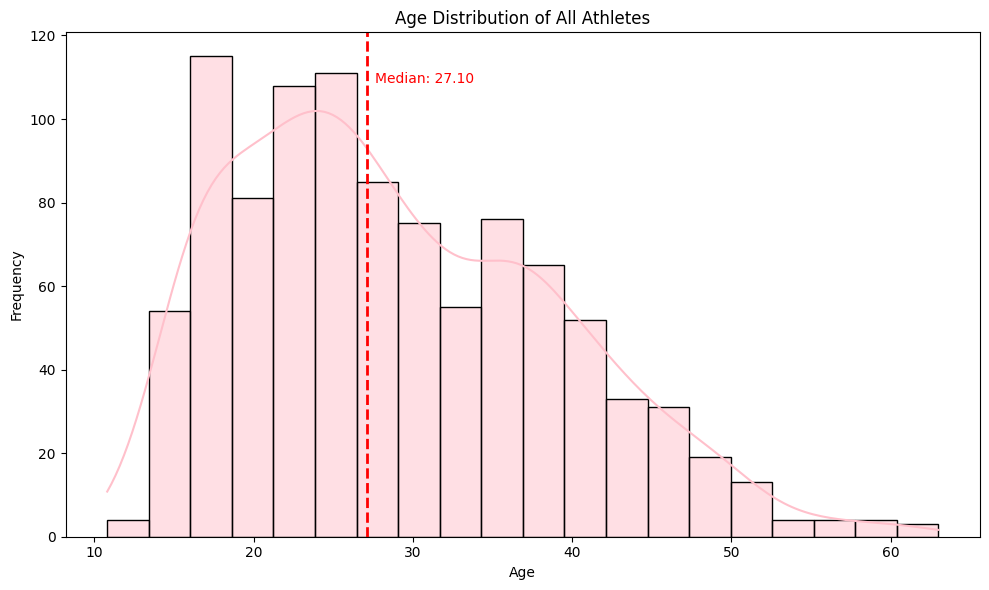

In [15]:
##2. Visualize age distribution of all athletes and display the median value in the chart.

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
subject_info = pd.read_csv("subject-info.csv")  
# Calculate the median age
median_age = subject_info['Age'].median()

# Plot the age distribution
plt.figure(figsize=(10, 6))
sns.histplot(subject_info['Age'], kde=True, bins=20, color='pink')

# Add a vertical line for the median
plt.axvline(median_age, color='red', linestyle='--', linewidth=2)
plt.text(median_age + 0.5, plt.ylim()[1] * 0.9, f'Median: {median_age:.2f}', color='red')

# Add titles and labels
plt.title('Age Distribution of All Athletes')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()

# Show the plot
plt.show()



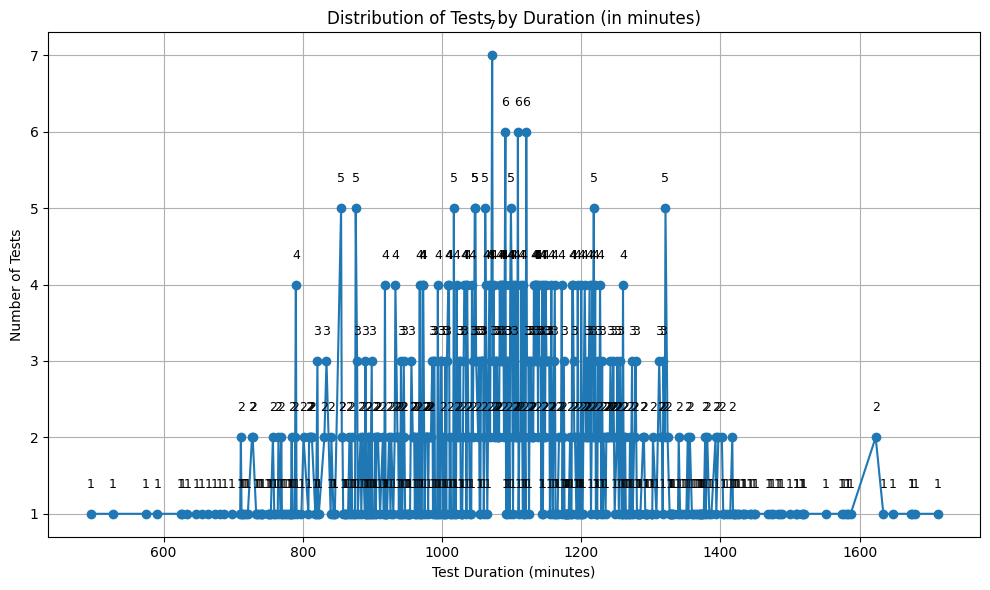

In [13]:
###3.Find the maximum time taken for all tests and then visualize the distribution of number of tests based on the test duration in minutes. 
##Use a line chart and display the count of tests in the chart as well.
import pandas as pd
import matplotlib.pyplot as plt

# Load the test_measure data
test_measure = pd.read_csv("test_measure.csv")  

# Calculate the max time (duration) for each test
test_durations = test_measure.groupby('ID_test')['time'].max()

# Count the number of tests for each duration
duration_counts = test_durations.value_counts().sort_index()

# Plot the distribution as a line chart
plt.figure(figsize=(10, 6))
plt.plot(duration_counts.index, duration_counts.values, marker='o', linestyle='-')
plt.title('Distribution of Tests by Duration (in minutes)')
plt.xlabel('Test Duration (minutes)')
plt.ylabel('Number of Tests')

# Annotate the counts on the chart
for x, y in zip(duration_counts.index, duration_counts.values):
    plt.text(x, y + 0.3, str(y), ha='center', va='bottom', fontsize=9)

plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
##4.Display the consolidated list of overweight or obese people based on their BMI.
import pandas as pd

# Load the subject-info data
subject_info = pd.read_csv("subject-info.csv")  

# Convert height from cm to meters
subject_info['Height_m'] = subject_info['Height'] / 100

# Calculate BMI
subject_info['BMI'] = subject_info['Weight'] / (subject_info['Height_m'] ** 2)

# Classify BMI categories
def classify_bmi(bmi):
    if bmi >= 30:
        return 'Obese'
    elif bmi >= 25:
        return 'Overweight'
    else:
        return 'Normal'

subject_info['BMI_Category'] = subject_info['BMI'].apply(classify_bmi)

# Filter only overweight or obese
overweight_obese = subject_info[subject_info['BMI_Category'].isin(['Overweight', 'Obese'])]

# Display the result
print(overweight_obese[['ID', 'Age', 'Weight', 'Height', 'BMI', 'BMI_Category']])


      ID   Age  Weight  Height        BMI BMI_Category
34   134  14.7    76.0   173.0  25.393431   Overweight
40   588  14.9    83.0   182.0  25.057360   Overweight
41    40  15.0    77.0   165.0  28.282828   Overweight
48   590  15.6    88.7   178.0  27.995203   Overweight
54   313  15.9    68.0   158.0  27.239224   Overweight
..   ...   ...     ...     ...        ...          ...
982  597  55.4    78.0   175.6  25.295635   Overweight
985  755  58.5    64.0   157.0  25.964542   Overweight
989  390  61.3   102.0   185.0  29.802776   Overweight
990  596  61.6    74.0   169.0  25.909457   Overweight
991  296  63.0    83.5   171.5  28.389532   Overweight

[294 rows x 6 columns]


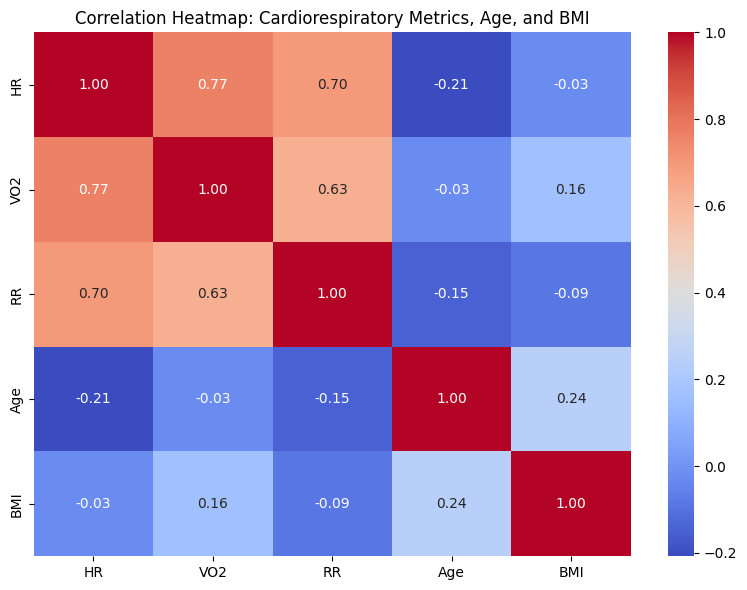

In [16]:
###5. Create a heatmap to visualize the correlations among any three cardiorespiratory measurements, Age, and BMI.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
subject_info = pd.read_csv("subject-info.csv")
test_measure = pd.read_csv("test_measure.csv")

# Calculate BMI
subject_info['Height_m'] = subject_info['Height'] / 100
subject_info['BMI'] = subject_info['Weight'] / (subject_info['Height_m'] ** 2)

# Merge both datasets on 'ID'
merged = pd.merge(test_measure, subject_info[['ID', 'Age', 'BMI']], on='ID')

# Select relevant columns
data = merged[['HR', 'VO2', 'RR', 'Age', 'BMI']]

# Compute correlation matrix
corr = data.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap: Cardiorespiratory Metrics, Age, and BMI")
plt.tight_layout()
plt.show()

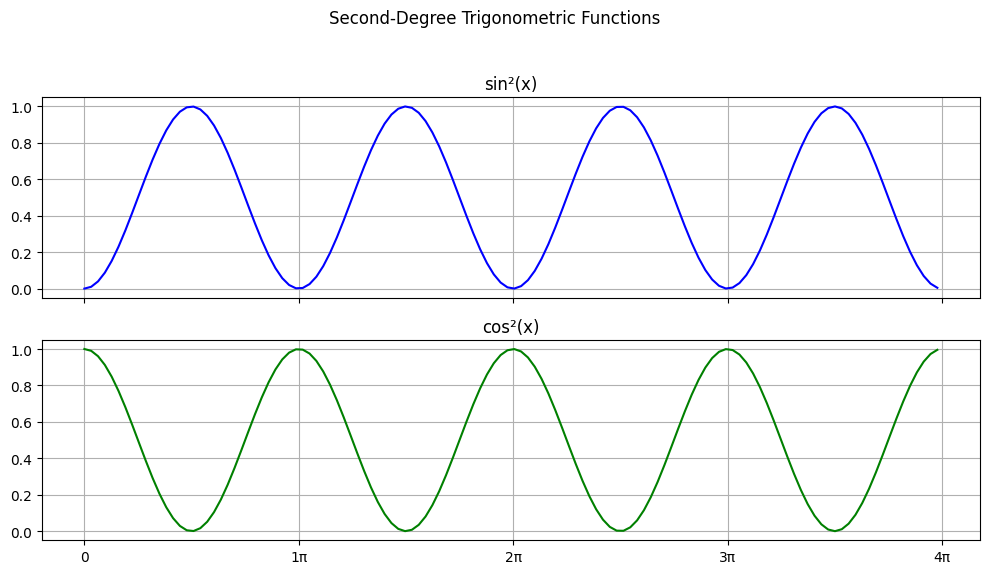

In [17]:
###6.Generate subplots for second-degree trigonometric functions,using x=np.arange(0,4*np.pi,0.1) in object oriented approach.
 ###Label every π interval on X axis.
import numpy as np
import matplotlib.pyplot as plt

# Create x values
x = np.arange(0, 4 * np.pi, 0.1)

# Calculate second-degree trigonometric functions
y1 = np.sin(x) ** 2
y2 = np.cos(x) ** 2

# Create figure and axes using object-oriented approach
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Plot sin²(x)
ax1.plot(x, y1, color='blue')
ax1.set_title('sin²(x)')
ax1.grid(True)

# Plot cos²(x)
ax2.plot(x, y2, color='green')
ax2.set_title('cos²(x)')
ax2.grid(True)

# Set x-ticks at every π interval
pi_ticks = np.arange(0, 4 * np.pi + 0.1, np.pi)
pi_labels = [f'{int(i)}π' if i > 0 else '0' for i in range(5)]
ax2.set_xticks(pi_ticks)
ax2.set_xticklabels(pi_labels)

# Set labels
fig.suptitle('Second-Degree Trigonometric Functions')
fig.tight_layout(rect=[0, 0.03, 1, 0.95])

# Show plot
plt.show()

In [30]:
##7. Get a number from the user and print its multiplication table from 1 to 10.

# Get input from the user
num = int(input("Enter a number: "))

# Print multiplication table
print(f"\nMultiplication Table for {num}:\n")
for i in range(1, 11):
    print(f"{num} x {i} = {num * i}")



Multiplication Table for 7:

7 x 1 = 7
7 x 2 = 14
7 x 3 = 21
7 x 4 = 28
7 x 5 = 35
7 x 6 = 42
7 x 7 = 49
7 x 8 = 56
7 x 9 = 63
7 x 10 = 70


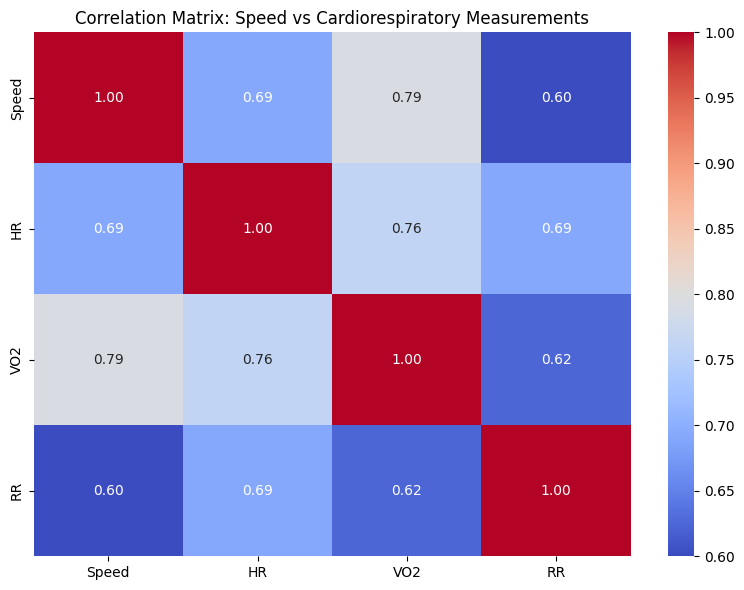

In [ ]:
##8.Write a function to display a correlation matrix between speed of the treadmill and any cardiorespiratory measurement  of the athelete.
##(Exclude warmup period).


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def show_correlation_matrix(file_path="test_measure.csv", measurements=None):
    """
    Displays a correlation matrix between Speed and selected cardiorespiratory measurements,
    excluding the warmup period (time == 0).
    
    Parameters:
    - file_path: str, path to the CSV file
    - measurements: list of str, cardiorespiratory measurement columns to include (e.g., ['HR', 'VO2'])
    """
    if measurements is None:
        measurements = ['HR', 'VO2', 'RR', 'VCO2', 'VE']  # Default measurements

    # Load the dataset
    df = pd.read_csv(file_path)

    # Exclude warmup period
    df = df[df['time'] > 0]

    # Select Speed and desired measurements
    selected_cols = ['Speed'] + [m for m in measurements if m in df.columns]
    data = df[selected_cols]

    # Compute correlation
    corr = data.corr()

    # Plot the heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix: Speed vs Cardiorespiratory Measurements')
    plt.tight_layout()
    plt.show()


show_correlation_matrix("test_measure.csv", measurements=['HR', 'VO2', 'RR'])

In [ ]:
##9. What percentage of athletes exceeded 90% of max HR after warm up period? 

import pandas as pd

# Load the datasets
subject_info = pd.read_csv("subject-info.csv")
test_measure = pd.read_csv("test_measure.csv")

# Remove warmup period
test_measure = test_measure[test_measure['time'] > 0]

# Merge data on athlete ID
merged = pd.merge(test_measure, subject_info[['ID', 'Age']], on='ID')

# Calculate 90% of max HR for each athlete
merged['Max_HR'] = 220 - merged['Age']
merged['HR_90_percent'] = 0.9 * merged['Max_HR']

# Check if any HR exceeds 90% max for each athlete
athletes_exceeded = merged[merged['HR'] > merged['HR_90_percent']]['ID'].unique()

# Total unique athletes
total_athletes = subject_info['ID'].nunique()

# Calculate percentage
percentage_exceeded = (len(athletes_exceeded) / total_athletes) * 100

print(f"{percentage_exceeded:.2f}% of athletes exceeded 90% of their max HR after the warmup period.")


95.80% of athletes exceeded 90% of their max HR after the warmup period.


In [27]:
####10.Which athlete spent the longest  time period in this exercise program to complete all of their cardiorespiratory measurements
##(including the time interval between different test cases)?
import pandas as pd

# Load test data
test_measure = pd.read_csv("test_measure.csv")

# Extract athlete ID from 'ID_test' (e.g., "1021_1" → 1021)
test_measure['ID'] = test_measure['ID_test'].apply(lambda x: int(str(x).split('_')[0]))

# Get the max time per test
max_time_per_test = test_measure.groupby('ID_test')['time'].max().reset_index()

# Extract athlete ID again
max_time_per_test['ID'] = max_time_per_test['ID_test'].apply(lambda x: int(str(x).split('_')[0]))

# Sum time across all tests for each athlete
total_time_per_athlete = max_time_per_test.groupby('ID')['time'].sum().reset_index()

# Identify the athlete with the longest total time
longest_athlete = total_time_per_athlete.loc[total_time_per_athlete['time'].idxmax()]

# Display the result
print(f"Athlete ID: {longest_athlete['ID']}")
print(f"Total Time Spent: {longest_athlete['time']} minutes")



Athlete ID: 506
Total Time Spent: 6017 minutes


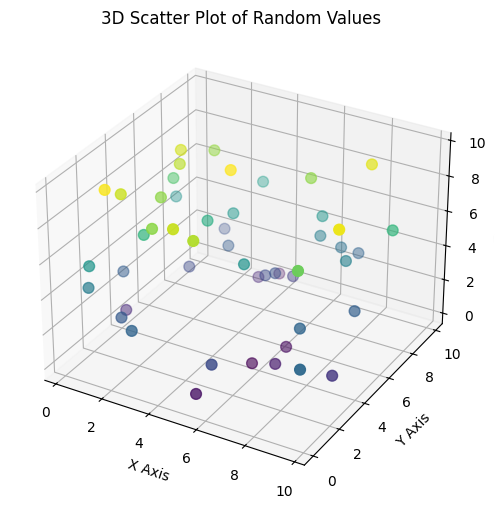

In [28]:
##11.Plot a 3-D graph using any set of random values chosen by you

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Generate random values
np.random.seed(42)
x = np.random.rand(50) * 10
y = np.random.rand(50) * 10
z = np.random.rand(50) * 10

# Create 3D plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
ax.scatter(x, y, z, c=z, cmap='viridis', marker='o', s=60)

# Axis labels
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
ax.set_title('3D Scatter Plot of Random Values')

plt.show()

In [ ]:
## 12.connect to database using PostgreSQL and get the details of participants in test 1 and age > 50

import psycopg2
import pandas as pd

# Connect to PostgreSQL
conn = psycopg2.connect(
    dbname="python_hack",
    user="postgres",
    password="Test123#",
    host="localhost",   # e.g., 'localhost'
    port="5433"    # e.g., '5432'
)

# Write SQL query
query = """
SELECT * FROM public.my_table WHERE  "ID_test"  ilike '%_1' AND "Age"::FLOAT > 50;

"""

# Run query and load into DataFrame
df = pd.read_sql_query(query, conn)

# Close connection
conn.close()

# Preview results
print(df.head())


    Age Weight Height Humidity Temperature Sex   ID ID_test
0  50.1     66    166       43        24.4   0  280   280_1
1  50.3     91    178       44        23.1   0  246   246_1
2  50.3     77    177       50        23.8   0  277   277_1
3  50.4     86    178       56        25.2   0  230   230_1
4  50.6     77    175       60        20.3   0  383   383_1


/var/folders/7_/5yr1rh2n33nfxxl9z1pcmhzm0000gn/T/ipykernel_53007/1253523215.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


In [33]:
##13.Make athelete ID as index to the subject_info table and arrange index in sorted order.
import pandas as pd

subject_info = pd.read_csv('subject-info.csv')  # From your uploaded file
# Create a new sorted DataFrame with 'ID' as index
subject_info_sorted = subject_info.set_index('ID').sort_index()

# Preview the result
subject_info_sorted.head()


,Age,Weight,Height,Humidity,Temperature,Sex,ID_test
ID,,,,,,,
1,32.7,67.0,173.5,NaN,NaN,0,1_1
2,33.8,68.0,171.1,NaN,NaN,0,2_1
3,16.6,63.8,176.0,43.0,24.6,0,3_1
4,28.5,88.0,181.3,NaN,NaN,0,4_1
5,23.4,85.0,181.4,NaN,NaN,0,5_1


In [34]:
 ##14.Calculate RER (Respiratory Exchange Ratio) , and categorize exercise phase to warmup, moderate, peak exercise according to RER

import pandas as pd
##test_measure = pd.read_csv("test_measure.csv")
# Calculate RER
test_measure['RER'] = test_measure['VCO2'] / test_measure['VO2']

# Categorize Exercise Phase based on RER
def categorize_phase(rer):
    if rer < 0.85:
        return 'Warm-up'
    elif 0.85 <= rer <= 1.00:
        return 'Moderate Exercise'
    else:
        return 'Peak Exercise'

test_measure['Exercise_Phase'] = test_measure['RER'].apply(categorize_phase)

# Preview the data
test_measure[['ID', 'time', 'VO2', 'VCO2', 'RER', 'Exercise_Phase']].head()


,ID,time,VO2,VCO2,RER,Exercise_Phase
0,2,0,478.0,360.0,0.753138,Warm-up
1,2,2,401.0,295.0,0.735661,Warm-up
2,2,4,449.0,319.0,0.710468,Warm-up
3,2,7,461.0,340.0,0.737527,Warm-up
4,2,9,574.0,417.0,0.726481,Warm-up


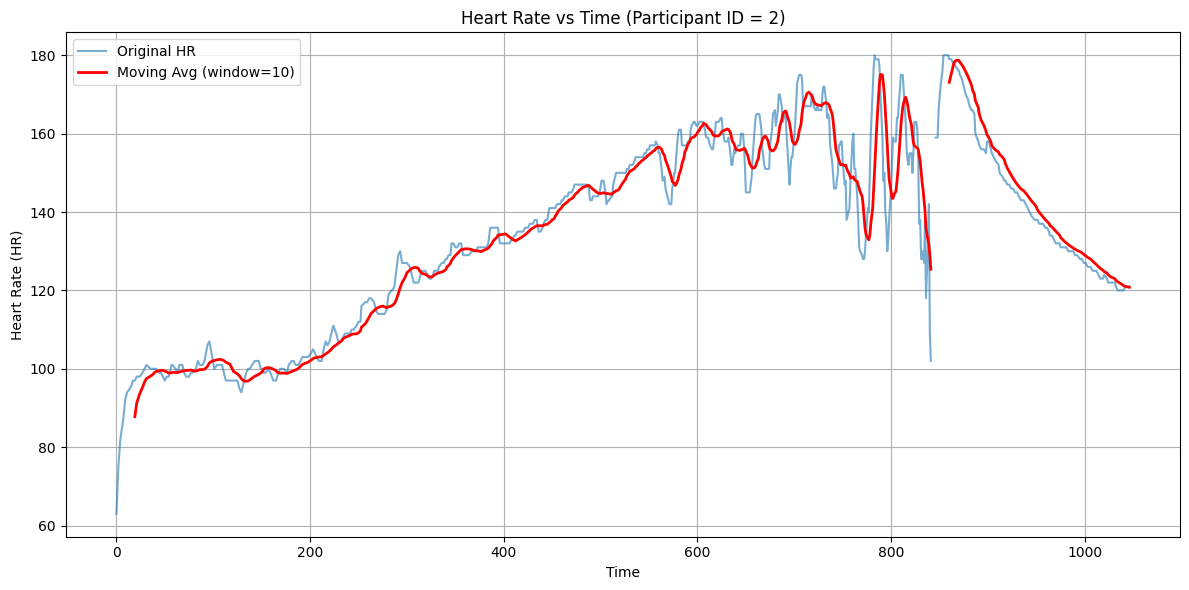

In [35]:
##15.Calculate the moving average(rolling mean) of HR for participant with ID 2 in a window size of 10 
##and plot a graph to show both moving average and original HR.
import pandas as pd
import matplotlib.pyplot as plt

# Filter data for participant ID 2
participant_2 = test_measure[test_measure['ID'] == 2]

# Sort by time (important for time-based data)
participant_2 = participant_2.sort_values(by='time')

# Calculate moving average (rolling mean) with window size 10
participant_2['HR_Moving_Avg'] = participant_2['HR'].rolling(window=10).mean()

# Plot original HR and moving average
plt.figure(figsize=(12, 6))
plt.plot(participant_2['time'], participant_2['HR'], label='Original HR', alpha=0.6)
plt.plot(participant_2['time'], participant_2['HR_Moving_Avg'], label='Moving Avg (window=10)', color='red', linewidth=2)

# Labels and legend
plt.title('Heart Rate vs Time (Participant ID = 2)')
plt.xlabel('Time')
plt.ylabel('Heart Rate (HR)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
## 16.What was the average time each test lasted for all athletes ?
# Step 1: Group by test session (assuming 'ID_test' identifies each test uniquely)
# If 'ID_test' doesn't exist, we can create it using 'ID' and 'test_no'

if 'ID_test' not in test_measure.columns:
    test_measure['ID_test'] = test_measure['ID'].astype(str) + '_' + test_measure['test_no'].astype(str)

# Step 2: Calculate duration per test session
test_durations = test_measure.groupby('ID_test')['time'].agg(lambda x: x.max() - x.min()).reset_index(name='test_duration')

# Step 3: Compute average duration
average_duration = test_durations['test_duration'].mean()

# Output
print(f"✅ Average test duration across all athletes: {average_duration:.2f} seconds")


✅ Average test duration across all athletes: 1092.03 seconds


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from pywaffle import Waffle

In [7]:
#Read the data from csv
df_subject = pd.read_csv('subject-info.csv')
df_test = pd.read_csv('test_measure.csv')

#Merge 2 datsets on participant ID
df_merge = pd.merge(df_subject,df_test, on='ID')

In [8]:
#Q17 - Display a histogram showing the distribution of athletes by their BMI values.


def display_histogram(filepath ='subject-info.csv'):
    
    #Read the excel file  
    df = pd.read_csv(filepath)  
    #Convert the Height to meters
    df['Height_meter'] = df['Height']/100
    #BMI=weight(kg)/(height(m))^2
    df['BMI'] = (df['Weight']/(df['Height_meter'] ** 2)).round(1)
    
    #Set the size of Histogram figure, title, color, x,y axis
    plt.figure(figsize=(10, 6))
    plt.hist(df['BMI'], bins=10, color='skyblue', edgecolor='black')
    plt.title('Distribution of Athletes by BMI')
    plt.xlabel('BMI')
    plt.ylabel('Number of Athletes')
    plt.grid(axis='y', alpha=0.4)
    plt.show()

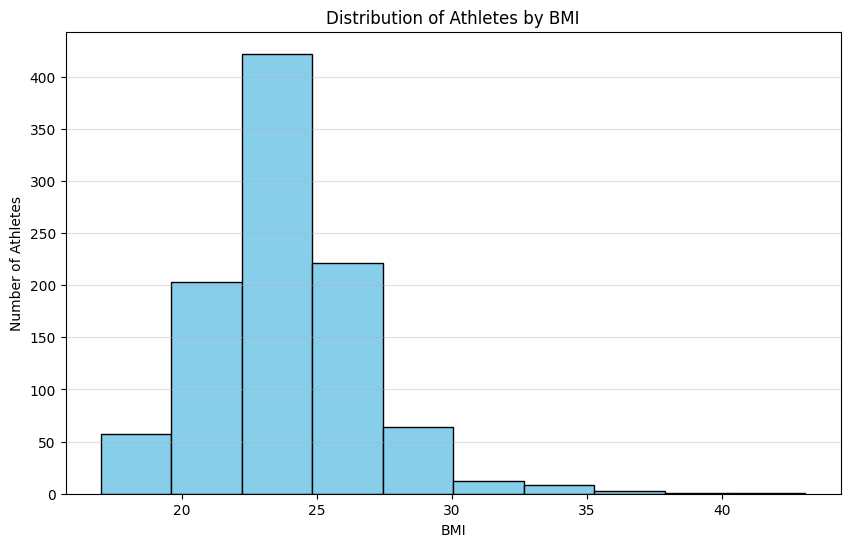

In [9]:
#Q17 - Display a histogram showing the distribution of athletes by their BMI values.
display_histogram()

In [10]:
#Q18 - Who is the tallest participant in the dataset? What is  his/her Vo2 kg/ml?


#Get the tallest participant's record
tallest_record = df_subject.loc[df_subject['Height'].idxmax()]

#Get the tallest participant's records rom merged dataset
tallest_reocords_merged = df_merge.loc[df_merge['ID']==tallest_record['ID']].copy()

#Get all VO2 record of tallest participant and convert into (ml/kg/min), round to 2 decimal places
#Converting ml/min to ml/kg/min. kg/ml as given in Question is not standard or meaningful unit.
tallest_reocords_merged['VO2'] = (tallest_reocords_merged['VO2']/tallest_record['Weight']).apply(lambda x: f"{x:.2f}")

print(f"Tallest Participant ID: {tallest_record['ID']}")
print(f"Tallest Participant Height is: {tallest_record['Height']} ", tallest_record['Height'], "cm" )
print(f"Tallest Participant (ID: {tallest_record['ID']}) VO2(ml/kg/min) Records: ")
display(tallest_reocords_merged[['ID','VO2']].style.hide(axis='index'))

Tallest Participant ID: 94
Tallest Participant Height is: 203.0  203.0 cm
Tallest Participant (ID: 94) VO2(ml/kg/min) Records: 


ID,VO2
94,8.64
94,11.54
94,8.60
94,10.06
94,10.53
94,11.01
94,11.59
94,13.01
94,13.02
94,13.83


In [11]:
#Q19 - What is the highest recorded heart rate?Identify the patient with the highest recorded heart rate.

#Get the highest Heart Rate and ID of the participant
highest_heartrate = df_test.loc[df_test['HR'].idxmax(),['ID','HR']]

#Display ID and HR with one decimal place
print("Highest recorded Heart rate and  ID of Participant with highest HR: ")
display(highest_heartrate.to_frame().T.style.hide(axis='index').format({'HR': '{:.1f}'}))


Highest recorded Heart rate and  ID of Participant with highest HR: 


ID,HR
619,226.0


In [12]:
#Q20 - What is the VO2 max(mL/kg/min) of the shortest male athlete?

#Filter the male athlete records
df_male = df_subject[df_subject['Sex']==0]

#Get the male athlete with the shortest Height
shortest_male = df_male.loc[df_male['Height'].idxmin()]


#Get the V02 of the shortest male athlete
shortest_male_VO2 =  df_merge.loc[df_merge['ID']==shortest_male['ID'],'VO2']

#Convert VO2 max to (mL/kg/min)
shortest_male_VO2_max = float(shortest_male_VO2.max()/shortest_male['Weight'])
shortest_male_VO2_max = shortest_male_VO2_max.__round__(2)

print(f"VO2 max(mL/kg/min) of the shortest male athlete is {shortest_male_VO2_max}(mL/kg/min)")

VO2 max(mL/kg/min) of the shortest male athlete is 49.62(mL/kg/min)


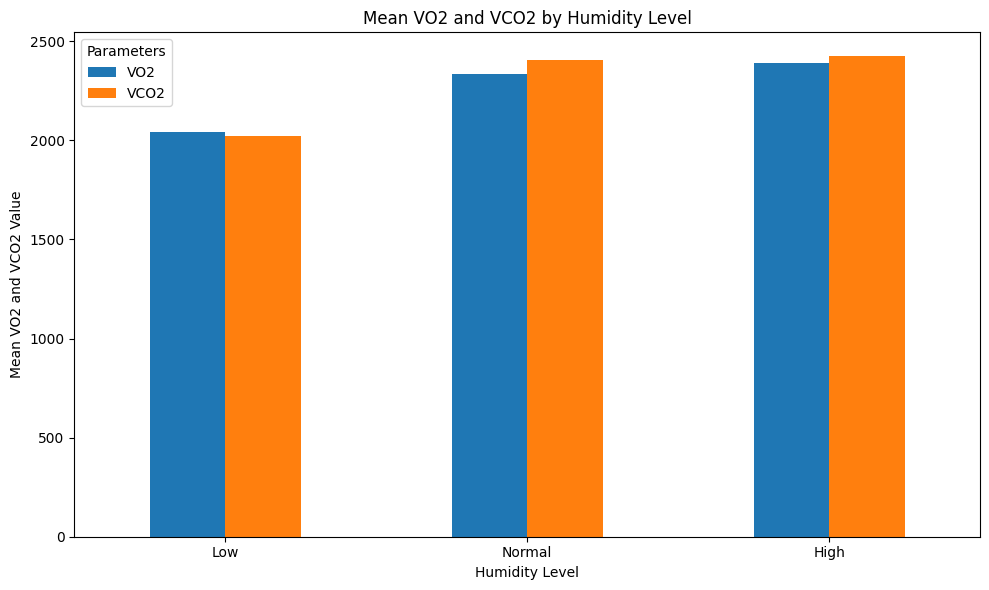

In [13]:
#Q21 - Analyze the mean VO2 and VCO2 values by humidity level using a Multiseries Bar Chart.

#convert  numerical humidity values into categorized ranges.
df_merge['Humidity_Level'] = pd.cut(df_merge['Humidity'], bins=[0,30,60,float('inf')], labels=['Low', 'Normal', 'High'])

#Calculate mean VO2 and VCO2 values for each humidity level
humiditygroup_data = df_merge.groupby(df_merge['Humidity_Level'], observed=False)[['VO2','VCO2']].mean()

humiditygroup_data.plot(kind='bar', figsize=(10, 6))
plt.title('Mean VO2 and VCO2 by Humidity Level')
plt.ylabel('Mean VO2 and VCO2 Value')
plt.xlabel('Humidity Level')
plt.xticks(rotation=0)
plt.legend(title='Parameters')
plt.tight_layout()

plt.show()

Observation for Q.21
Participants exposed to low humidity conditions exhibited reduced mean VO₂ and VCO₂ levels, suggesting a possible correlation between humidity and  VO₂ and VCO₂ levels

In [14]:
#Q22 - Display the average speed of each participant  in ' peak exercise' based on RER, (Following question no.14)

#Calculate the RER of each participant in the test
df_test['RER'] = (df_test['VCO2']/df_test['VO2']).round(2)

#Function to Assign exercise phase based on RER value
def assign_rer(rer):
    if rer < 0.85:
        return 'Warm-Up Exercise'
    elif rer <= 1.0:
        return 'Moderate Exercise'
    else:
        return 'Peak Exercise'
    
df_test['Exercise_Phase'] = df_test['RER'].apply(assign_rer)

#Filter only the Peak Exercise records
df_peak_exercise = df_test[df_test['Exercise_Phase'] == 'Peak Exercise']

#Calculate the average speed of each participant in Peak Exercise
athlete_avg_speed = df_peak_exercise.groupby('ID')['Speed'].mean().reset_index()

athlete_avg_speed.columns = ['ID', 'Average Speed']
display(athlete_avg_speed.style.hide(axis='index').format({'Average Speed': '{:.2f}'}))

ID,Average Speed
1,9.93
2,10.82
3,12.00
4,10.78
5,9.02
6,11.94
7,9.70
8,9.62
9,8.48
10,11.29


In [15]:
#Q23 - Assign one of the following 5 heart rate zones for every Athletes and add this as a column to a new table with all unique IDs. Exclude Warm-Up Phase

#As per the Question Zones should be assigned based on HR max of the athlete, so grouping by athlete ID and taking HR max

#Exclude warm up phase
df_test_excludewarmup =df_test[ df_test['Speed'] > 5].copy()

#Get Max HR for every athlete and name the column as HR_max
athlete_hr_max = df_test_excludewarmup.groupby('ID').agg(HR_max=('HR','max')).reset_index()

#Assign HR Zone
def assign_heartrate_zone(hr_max):
    if hr_max < 100:
        return 'Zone 1 (recovery/easy)'
    elif hr_max < 120:
        return 'Zone 2 (aerobic/base)'
    elif hr_max < 135:
        return 'Zone 3 (tempo)'
    elif hr_max < 155:
        return 'Zone 4 (lactate threshold)'
    else:
        return 'Zone 5 (anaerobic)'

#Apply HR Zone to each athlete based on max HR  
athlete_hr_max['HR Zone'] = athlete_hr_max['HR_max'].apply(assign_heartrate_zone)

#Create a new table with unique athlete ID's and HR Zone
hr_zone = (athlete_hr_max.drop_duplicates('ID')
                  .loc[:, ['ID', 'HR Zone']]
                  
)            
                        
hr_zone.style.hide(axis='index')


ID,HR Zone
1,Zone 5 (anaerobic)
2,Zone 5 (anaerobic)
3,Zone 5 (anaerobic)
4,Zone 5 (anaerobic)
5,Zone 5 (anaerobic)
6,Zone 5 (anaerobic)
7,Zone 5 (anaerobic)
8,Zone 5 (anaerobic)
9,Zone 5 (anaerobic)
10,Zone 5 (anaerobic)


In [16]:
#Q24 - Find the athlete who has got optimal respiratory stability based on the measure of  Breathing Interval variability over time.

#Calculate duration of a breath in seconds
df_test['BI'] = 60/ df_test['RR']

#Group by athlete and calculate mean and std.deviation
mean_std_bi_athlete = df_test.groupby('ID')['BI'].agg(['mean','std'])

#Calculate Coefficient of Variation (CV) of BI
mean_std_bi_athlete['CV'] = mean_std_bi_athlete['std']/mean_std_bi_athlete['mean']

#Lower CV = more stable breathing.
athlete_respiratory_stability = mean_std_bi_athlete['CV'].idxmin()

print(f"ID of the Athlete who has got optimal respiratory stability is: {athlete_respiratory_stability}")


ID of the Athlete who has got optimal respiratory stability is: 235


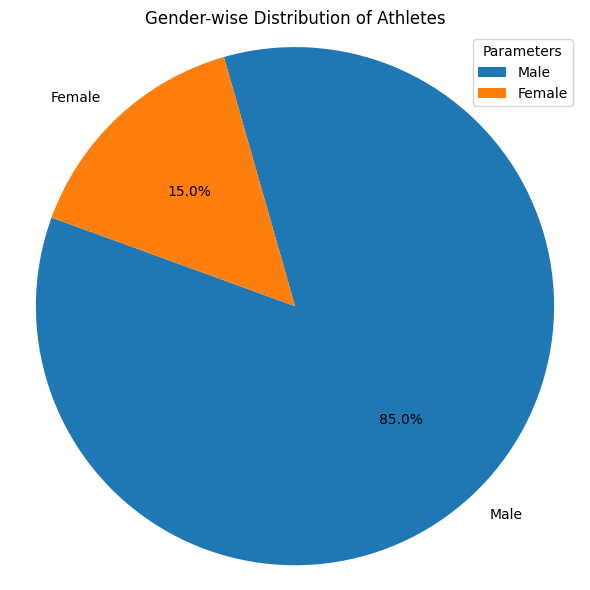

In [17]:
#Q25 - Generate a pie chart to show the gender-wise distribution of athletes.


#Map 0 to Male and 1 to Female
df_subject['gender_label'] = df_subject['Sex'].map({0: 'Male', 1: 'Female'})

#Count the genders
df_gender_count = df_subject['gender_label'].value_counts()
df_gender_count

#Plot Pie chart
plt.figure(figsize=(6, 6))
plt.pie(df_gender_count, labels=df_gender_count.index, autopct='%1.1f%%', startangle=160)
plt.title('Gender-wise Distribution of Athletes')
plt.legend(title='Parameters')
plt.axis('equal')  # Equal aspect ratio ensures a perfect circle.
plt.tight_layout()
plt.show()

In [22]:
#Q26 - Use enumeration to print ID, Sex, and BMI of each athlete.

print(f"{'ID':<10}{'Gender':<12}{'BMI':<10}")
print("-" * 30)

df_subject['BMI'] = (df_subject['Weight'] / ((df_subject['Height']/100) ** 2)).round(1)
for i, row in enumerate(df_subject.itertuples(),start=1):
    print(f"{row.ID:<10} {row.gender_label:<10} {row.BMI:<10}")   


ID        Gender      BMI       
------------------------------
543        Female     18.4      
11         Female     18.2      
829        Male       18.0      
284        Female     19.7      
341        Male       18.7      
341        Male       18.3      
343        Male       18.0      
330        Male       17.5      
338        Male       18.4      
339        Male       19.4      
343        Male       17.9      
333        Male       22.5      
335        Male       21.1      
339        Male       19.2      
344        Male       21.4      
607        Male       21.2      
331        Male       19.1      
333        Male       22.3      
342        Male       20.4      
546        Male       19.2      
557        Female     19.9      
132        Male       17.9      
331        Male       18.5      
332        Male       18.7      
334        Male       20.2      
336        Male       17.1      
340        Male       19.6      
132        Male       17.8      
334        M

In [23]:
#Q27 - Create a sunburst chart to show the distribution of athletes based on Sex, BMI levels, and Age ranges.

#Categorize BMI
def bmi_level(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"
    
#Categorize BMI  
def age_range(age):
    if age < 20:
        return "<20"
    elif age < 30:
        return "20-29"
    elif age < 40:
        return "30-39"
    elif age < 50:
        return "40-49"
    else:
        return "50+"
    
#Aply BMI levels and Age ranges to each athlete
df_subject['BMI_Level'] = df_subject['BMI'].apply(bmi_level)
df_subject['AGE_Range'] = df_subject['BMI'].apply(age_range)

plot = px.sunburst(df_subject,
                   path=['gender_label','BMI_Level','AGE_Range'],
                   values=None,
                   title="Athlete Distribution by Sex, BMI Levels, and Age Ranges",
                   width=800,
                   height=800
)

plot.show()

In [24]:
#Q28 -  Create a dictionary using any 5 random Athletes ID and their height. Access any one height using the Athlete ID with get() function. 

#Get 5 random athletes
df_random_athletes = df_subject.sample(5)

#Create a dictionary with ID as key and Height of athlete as value
random_athletes_dict = dict(zip(df_random_athletes['ID'],df_random_athletes['Height']))

#Get the ID of first athlete from dictionary
random_athlete_id = list(random_athletes_dict.keys())[0]

#Use get() to to access Height of thefirst athlete from dictionary
random_athlete_height = random_athletes_dict.get(random_athlete_id)

print(f"Dictionary:{random_athletes_dict}")
print(f"Height of Athlete with ID {random_athlete_id} is: {random_athlete_height}")

Dictionary:{300: 178.0, 236: 179.0, 220: 185.0, 96: 181.0, 134: 173.0}
Height of Athlete with ID 300 is: 178.0


In [25]:
#Q29 - Find which age range has the highest number of obese athletes

#Filter Obese athletes
df_obese_athletes = df_subject[df_subject['BMI_Level']=='Obese']

#Get The count of all Age ranges for obese athletes
age_range_counts = df_obese_athletes['AGE_Range'].value_counts()

#Get the age range with max count
max_age_range = age_range_counts.idxmax()

print(f"Age Range that has the highest number of obese athletes is : {max_age_range}")


Age Range that has the highest number of obese athletes is : 30-39


C:\Users\chait\AppData\Local\Temp\ipykernel_440\542391254.py:28: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



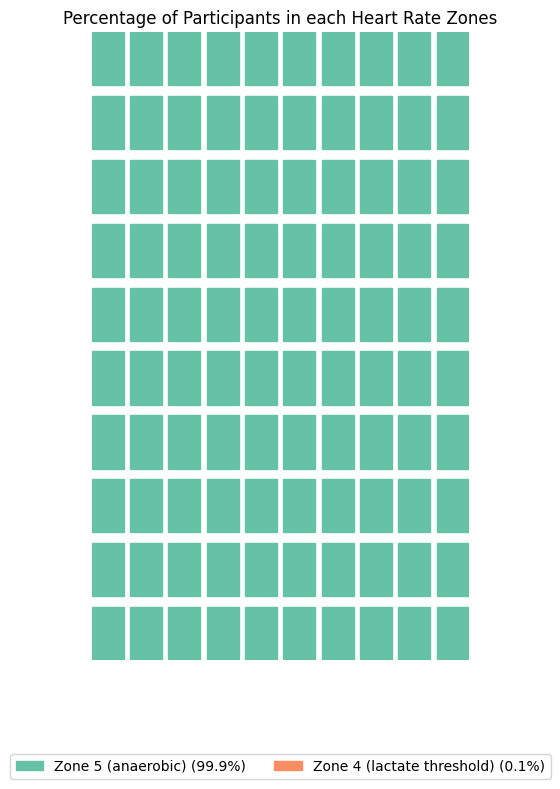

In [26]:
#Q.30 Create a waffle chart to show the percentage of participant in each HR zone. (followed by question 23)

#As per the Question.23 Zones should be assigned based on HR max of the athlete, so grouping by athlete ID and taking HR max

#Count the number of participants in each HR zone
zone_counts = hr_zone['HR Zone'].value_counts()

#Total Particpants
total_participants = len(hr_zone)

#Calculate the percentage of participants in each HR zone
hr_zone_percentage = {zone: count/total_participants *100
                      for zone,count in zone_counts.items()}

#Display Waffle chart
plot = plt.figure(
    figsize=(12, 8),
    FigureClass=Waffle,
    rows=10,
    values=hr_zone_percentage,   
    title={'label': 'Percentage of Participants in each Heart Rate Zones', 'loc': 'center'},
    labels=[f"{k} ({v:.1f}%)" for k,v in hr_zone_percentage.items()],
    legend={'loc': 'lower center', 'bbox_to_anchor': (0.5, -0.2), 'ncol': 3},
    block_aspect_ratio=0.6, 
        
)

plot.show()



In [27]:
#Q.31 Calculate the Tidal volume of every athlete and display it as a list.

#Calculate Tidal Volume using the formula: Tidal Volume = VE/RR
df_test['Tidal_Volume'] = (df_test['VE']/df_test['RR']).round(2)

#Convert to list
athlete_tidal_volume_list = df_test['Tidal_Volume'].tolist()

athlete_tidal_volume_list

[0.49,
 0.45,
 0.42,
 0.46,
 0.52,
 0.6,
 0.59,
 0.63,
 0.71,
 0.7,
 0.69,
 0.72,
 0.67,
 0.7,
 0.64,
 0.64,
 0.65,
 0.6,
 0.61,
 0.59,
 0.57,
 0.6,
 0.6,
 0.66,
 0.69,
 0.67,
 0.65,
 0.66,
 0.66,
 0.72,
 0.7,
 0.69,
 0.69,
 0.75,
 0.75,
 0.8,
 0.79,
 0.8,
 0.83,
 0.83,
 0.83,
 0.78,
 0.84,
 0.84,
 0.88,
 0.88,
 0.88,
 0.85,
 0.86,
 0.85,
 0.89,
 0.84,
 0.8,
 0.76,
 0.74,
 0.72,
 0.8,
 0.76,
 0.82,
 0.79,
 0.79,
 0.83,
 0.86,
 0.81,
 0.79,
 0.73,
 0.72,
 0.77,
 0.7,
 0.7,
 0.72,
 0.74,
 0.75,
 0.8,
 0.79,
 0.87,
 0.85,
 0.86,
 0.95,
 0.94,
 0.89,
 0.94,
 0.82,
 0.82,
 0.87,
 0.86,
 0.96,
 0.93,
 0.95,
 0.95,
 0.85,
 0.78,
 0.79,
 0.79,
 0.79,
 0.79,
 0.79,
 0.84,
 0.86,
 0.89,
 0.87,
 0.92,
 0.94,
 0.92,
 0.88,
 0.91,
 0.88,
 0.86,
 0.85,
 0.86,
 0.89,
 0.78,
 0.82,
 0.86,
 0.92,
 0.99,
 0.93,
 0.99,
 1.04,
 0.95,
 0.91,
 0.91,
 0.85,
 0.97,
 0.93,
 0.94,
 0.98,
 0.97,
 1.0,
 1.06,
 1.06,
 1.01,
 1.03,
 0.98,
 1.22,
 1.13,
 1.04,
 0.82,
 0.88,
 0.91,
 1.02,
 1.04,
 1.07,
 1.06,
 1.12,


In [28]:
#Q.32 create a Pivot table to summarize the count of each HR Zone

#As per the Question.23 Zones should be assigned based on HR max of the athlete, so grouping by athlete ID and taking HR max

#Group the data based on HR Zone and count the number of participants in each zone
hr_zone_pivot = hr_zone.pivot_table(index='HR Zone', aggfunc='size').reset_index()

#Rename the columns
hr_zone_pivot.columns = ['HR Zone', 'Count']

display(hr_zone_pivot.style.hide(axis='index'))

HR Zone,Count
Zone 4 (lactate threshold),1
Zone 5 (anaerobic),856


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#reading csv and handling null values
df_subject = pd.read_csv('subject-info.csv').dropna(subset=['Age', 'Height', 'Weight'])
df_test = pd.read_csv('test_measure.csv').dropna(subset=['HR', 'RR', 'Speed'])

In [35]:
#34. Create an array , np.arange(12).reshape(3,4). Replace the array elements with their square values if the element is an even number. Keep the odd numbers as such. Display the resulting array.

# Creating an array
array_original=np.arange(12).reshape(3,4)

#Using np.where condition
resulting_array=np.where(array_original%2==0, np.square(array_original), array_original)

print(resulting_array)

[[  0   1   4   3]
 [ 16   5  36   7]
 [ 64   9 100  11]]


In [36]:
#35. Read 10 records from dataframe and convert into json format and print the data

first_ten_records=df_subject.head(10)

#converting into JSON Format
json_data = first_ten_records.to_json(orient='records', lines=True)
print(json_data)

{"Age":10.8,"Weight":48.8,"Height":163.0,"Humidity":39.0,"Temperature":20.7,"Sex":1,"ID":543,"ID_test":"543_1","gender_label":"Female","BMI":18.4,"BMI_Level":"Underweight","AGE_Range":"<20"}
{"Age":11.8,"Weight":41.0,"Height":150.0,"Humidity":41.0,"Temperature":22.3,"Sex":1,"ID":11,"ID_test":"11_1","gender_label":"Female","BMI":18.2,"BMI_Level":"Underweight","AGE_Range":"<20"}
{"Age":12.2,"Weight":46.0,"Height":160.0,"Humidity":37.0,"Temperature":21.5,"Sex":0,"ID":829,"ID_test":"829_1","gender_label":"Male","BMI":18.0,"BMI_Level":"Underweight","AGE_Range":"<20"}
{"Age":13.2,"Weight":71.0,"Height":190.0,"Humidity":49.0,"Temperature":23.8,"Sex":1,"ID":284,"ID_test":"284_1","gender_label":"Female","BMI":19.7,"BMI_Level":"Normal","AGE_Range":"<20"}
{"Age":13.7,"Weight":53.8,"Height":169.7,"Humidity":40.0,"Temperature":25.3,"Sex":0,"ID":341,"ID_test":"341_1","gender_label":"Male","BMI":18.7,"BMI_Level":"Normal","AGE_Range":"<20"}
{"Age":13.8,"Weight":53.4,"Height":171.0,"Humidity":42.0,"Tem

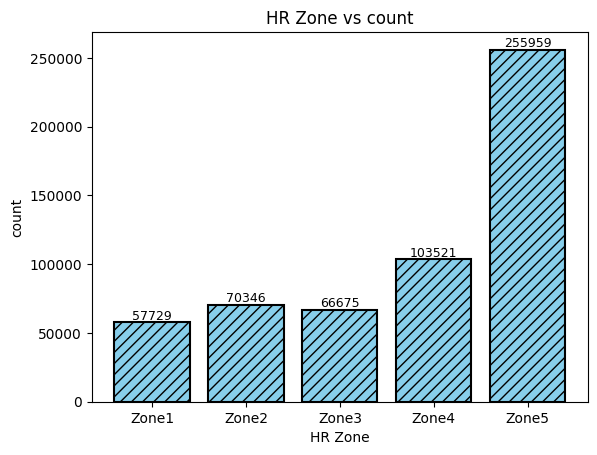

In [38]:
#36. Create a barchart for HR Zone vs count and apply hatches to the bars.

#removing rows that has missing values in HR Column
df_test = df_test.dropna(subset=['HR']) 

#hr-zones based on Q)23
def hr_zones(hr):
    if hr<100:
        return "Zone1"   #-(recovery/easy)
    elif hr<120:
        return "Zone2"   #-(aerobic/base)
    elif hr<135:
        return "Zone3"   #-(tempo)
    elif hr<155:
        return "Zone4"   #-(lactate threshold)
    else:
        return "Zone5"   #-(anaerobic)

#applying to each row
df_test['hr_zones']=df_test['HR'].apply(hr_zones)

#count of zone in each row
count_of_zone = df_test['hr_zones'].value_counts().sort_index()

# Plotting Bar Chart
bars = plt.bar(count_of_zone.index, count_of_zone.values,hatch='///', color='skyblue', edgecolor='black', linewidth=1.5)

# Label the bars
for bar in bars:
    yval = bar.get_height()  # Get the height (value) of each bar
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, str(int(yval)), 
             ha='center', va='bottom', fontsize=9)

#Plotting Bar Chart
plt.xlabel("HR Zone") 
plt.ylabel("count")
plt.title("HR Zone vs count")
plt.show()

In [39]:
#37.Who is the youngest athlete and how many tests did she take part in?

#Only rows where gender is female which is 1
female_athlete = df_subject[df_subject['Sex'] == 1]

#youngest athlete whose age is minimum
youngest_athlete = female_athlete['Age'].min()

#finding the youngest female athlete row
youngest_female_athlete=female_athlete[female_athlete['Age'] == youngest_athlete].iloc[0]

#getting her ID
youngest_female_athlete_ID=youngest_female_athlete['ID']

print(f"Youngest female athlete ID is:{youngest_female_athlete_ID} and her age is {youngest_athlete}")

#no of tests she took part 
no_of_tests = df_test[df_test['ID'] == youngest_female_athlete_ID]
total_tests = no_of_tests.shape[0]

print(f"No of tests She took part in: {total_tests}")

Youngest female athlete ID is:543 and her age is 10.8
No of tests She took part in: 526


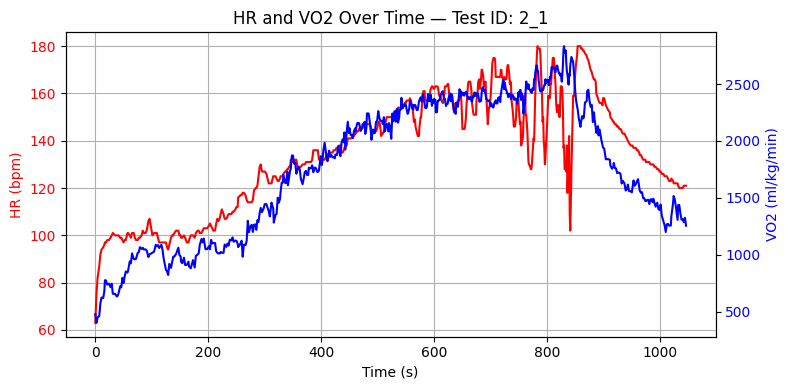

In [40]:
#38.Plot the changes in HR and VO2 over time for each ID_test. Add a trendline to compare the HR and VO2 changes.

# Step 2: Pick one test ID
test_id = df_test['ID_test'].dropna().unique()[0]
df_test = df_test[df_test['ID_test'] == test_id]

#plotting
fig, axis1 = plt.subplots(figsize=(8, 4))

# Plot HR on primary y-axis
axis1.plot(df_test['time'], df_test['HR'], color='red', label='HR')
axis1.set_xlabel('Time (s)')
axis1.set_ylabel('HR (bpm)', color='red')
axis1.tick_params(axis='y', labelcolor='red')

# Plot VO2 on secondary y-axis
axis2 = axis1.twinx()
axis2.plot(df_test['time'], df_test['VO2'], color='blue', label='VO2')
axis2.set_ylabel('VO2 (ml/kg/min)', color='blue')
axis2.tick_params(axis='y', labelcolor='blue')

# Title and Grid
plt.title(f'HR and VO2 Over Time — Test ID: {test_id}')
axis1.grid(True)
plt.tight_layout()
plt.show()        

#since there are 992 tests, we are plotting for single test. We can do the same for all tests

In [41]:
#39.Find the average HRV for individual athletes, using short-term variability analysis(RMSSD).
#Used to measure Heart Rate Variability (HRV), how much heart rate changes from beat to beat

df_test = pd.read_csv('test_measure.csv').dropna(subset=['RR'])

#calculating RMSSD
def func_rmssd(rr_interval_values):
    # difference between RR values
    diff_rr = np.diff(rr_interval_values)    
    #Square the differences
    squared_difference = diff_rr**2    
    #mean of squared differences and applying square root
    rmssd = np.sqrt(np.mean(squared_difference))
    return rmssd

#calculate rmssd for each athlete
athlete_rmssd = df_test.groupby('ID')['RR'].apply(func_rmssd)

# rmssd dataFrame for display
rmssd_df = athlete_rmssd.reset_index()
rmssd_df.columns = ['ID', 'RMSSD']

#result
print("Average HRV per athlete:")
print(rmssd_df)

Average HRV per athlete:
      ID     RMSSD
0      1  0.974321
1      2  1.243954
2      3  2.000829
3      4  1.607636
4      5  1.461686
..   ...       ...
852  853  1.418076
853  854  1.649630
854  855  1.441412
855  856  2.802726
856  857  1.631976

[857 rows x 2 columns]


In [42]:
#40. Identify the test that took the longest time to complete.

#max time per test
test_durations = df_test.groupby('ID_test')['time'].max()

#test with the longest time
longest_test_id = test_durations.idxmax()
longest_time = test_durations.max()

print("Test that took Longest Time to complete:")
print(f"Test ID: {longest_test_id} and  Duration: is {longest_time} seconds")

Test that took Longest Time to complete:
Test ID: 699_1 and  Duration: is 1712 seconds


In [ ]:
#41. Perform an EDA of subject_info using YDATA Profiling.

##Use python version below 3.13.0

##Installing the package
pip install ydata-profiling  #Use python version below 3.13.0

##Import the libraries
import pandas as pd
from ydata_profiling import ProfileReport #Use python version below 3.13.0

##Read the data
df_subject = pd.read_csv("subject_info.csv")

##Generate Profile Report
##subject_info_report = ProfileReport(df_subject, title="EDA of subject_info", explorative=True)
subject_info_report = ProfileReport(df_subject, title = "EDA of subject_info")

##subject_info_report.to_file(output_file = 'Report_subject_info.html')
##For Jupyter Notebook -profile.to_notebook_iframe()

## Display the report in the notebook
subject_info_report.to_notebook_iframe()

For Q.41, To generate EDA report using YDATA profiling, use python version below 3.13.0.

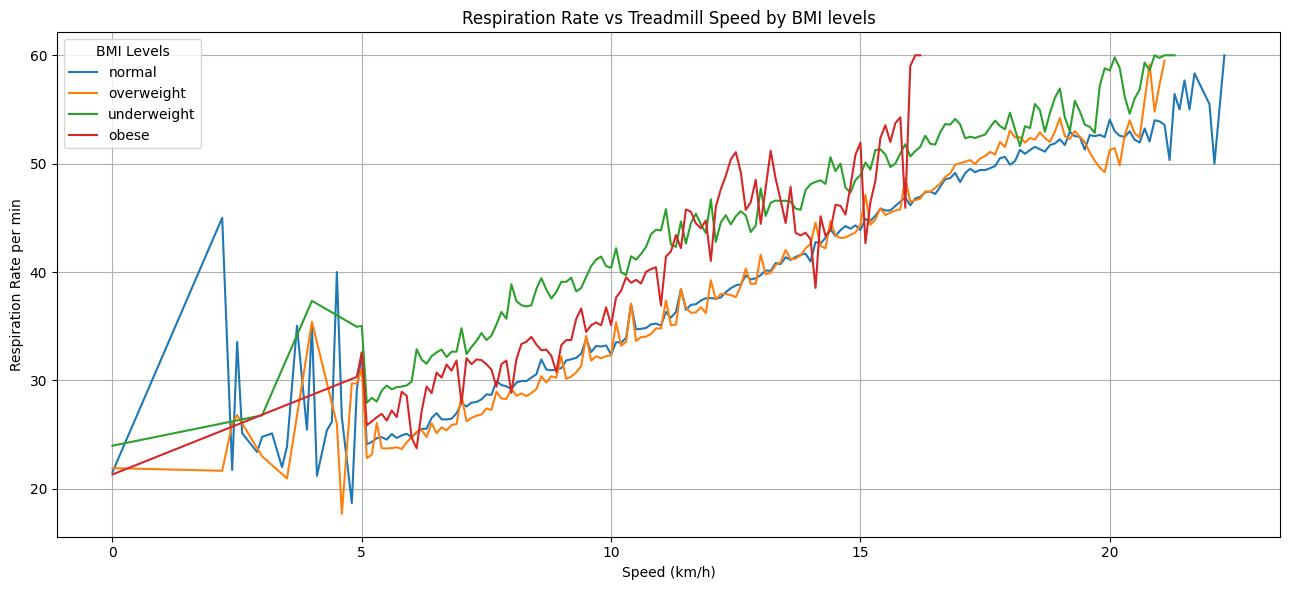


 *BMI level with highest average respiratory rate is:*
underweight level with 39.79 per min


In [43]:
#42.How does respiration rate progress based on treadmill speed for different BMI levels? Visualize this relationship and find which BMI level has the highest mean respiration rate?"

# Convert height from cm to meters
df_subject['Height_m'] = df_subject['Height'] / 100

# Calculate BMI
df_subject['BMI'] = df_subject['Weight'] / (df_subject['Height_m'] ** 2)

#merge on participant ID
df_merge = pd.merge(df_test,df_subject, on='ID')

#BMI Levels
def bmi_levels(bmi):
    if bmi<18.5:
        return 'underweight'
    elif bmi<25:
        return 'normal'
    elif bmi<30:
        return 'overweight'
    else:
        return 'obese'
   
df_merge['BMI levels'] = df_merge['BMI'].apply(bmi_levels)

#visualizing relation between respiration rate and treadmill
plt.figure(figsize=(13,6))
sns.lineplot(data=df_merge, x='Speed', y='RR', hue='BMI levels',errorbar=None)
plt.title("Respiration Rate vs Treadmill Speed by BMI levels")
plt.xlabel("Speed (km/h)")
plt.ylabel("Respiration Rate per min")
plt.legend(title="BMI Levels")
plt.grid(True)
plt.tight_layout()
plt.show()

#BMI level with highest average Resp Rate
mean_highest_avg_rr = df_merge.groupby('BMI levels')['RR'].mean()

print("\n *BMI level with highest average respiratory rate is:*")
print(f"{mean_highest_avg_rr.idxmax()} level", "with", round(mean_highest_avg_rr.max(), 2), "per min")


In [46]:
#Repeating same question 2nd time, will delete later once the right solution is confirmed
#43. Identify cases of possible bradycardia at rest and display number of athletes based on gender.

#bradycardia - slow heart rate<60
bradycardia_df = df_test[df_test['HR'] < 60]

df_merge['Gender'] = df_merge['Sex'].map({0: 'Male', 1: 'Female'})

#no.of athletes based on gender
no_of_athletes=df_merge['Gender'].value_counts()

print(f"no of athletes with possible bradycardia cases are:")
print(no_of_athletes)

no of athletes with possible bradycardia cases are:
Gender
Male      649437
Female     95589
Name: count, dtype: int64


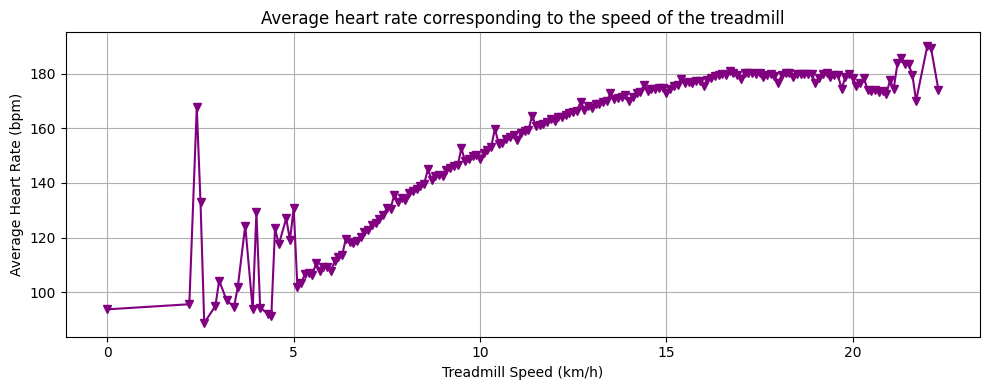

In [47]:
#44. Calculate the average heart rate corresponding to the speed of the treadmill and  plot a line graph to visualize the relationship.

avg_heart_rate=df_test.groupby('Speed')['HR'].mean()

#plotting the line graph
plt.figure(figsize=(10,4))
plt.plot(avg_heart_rate.index,avg_heart_rate.values, marker='v', linestyle='-', color='purple')
plt.title("Average heart rate corresponding to the speed of the treadmill")
plt.xlabel("Treadmill Speed (km/h)")
plt.ylabel("Average Heart Rate (bpm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
#45. Analyze the trend of HR at the start of the test vs the middle and the end. What is the overall trend?
# Drop missing HR
df_test = df_test.dropna(subset=['HR'])  

# storing mean HR for each test
start_test_mean = []
middle_test_mean = []
end_test_mean = []

#for each test
for test_id, test_data in df_test.groupby('ID_test'):
    test_data = df_test[df_test['ID_test'] == test_id].sort_values('time').reset_index(drop=True)
    n = len(test_data)   
    if n >= 3:  
        one_third = n // 3
        #slicing
        start_test_slice = test_data.iloc[:one_third]
        middle_test_slice = test_data.iloc[one_third:2*one_third]
        end_test_slice = test_data.iloc[2*one_third:]

        start_test_mean.append(start_test_slice['HR'].mean())
        middle_test_mean.append(middle_test_slice['HR'].mean())
        end_test_mean.append(end_test_slice['HR'].mean())

#summary
overall_trend = pd.DataFrame({
    'Start_test': start_test_mean,
    'Middle_test': middle_test_mean,
    'End_test': end_test_mean})

# Overall average trend
overall_mean = overall_trend.mean()
print("\n Overall Avg HR trend (bpm) across tests:")
print("HR increases in the middle of the test and drops at the end of test")
print(overall_mean.to_dict())



 Overall Avg HR trend (bpm) across tests:
HR increases in the middle of the test and drops at the end of test
{'Start_test': 115.23817679977192, 'Middle_test': 163.33493430997905, 'End_test': 159.53236039605724}


In [52]:
#46. Find the oldest athlete in the dataset and determine the number of breaths recorded for the oldest athlete during the test.

oldest_athelete = df_subject[df_subject['Age'] == df_subject['Age'].max()]
oldest_id = oldest_athelete['ID'].values[0]

#breathe of oldest athlete
breath_count = df_test[df_test['ID'] == oldest_id]['RR'].count()

print(f"\n Number of breaths recorded for the oldest athlete during the test: {breath_count}")


 Number of breaths recorded for the oldest athlete during the test: 345


In [53]:
#47Assuming age is given for the current year(2025),list the participants born on leap year

#calculate year of birth
df_subject['Year of Birth']= 2025 - df_subject['Age']

#leap year
def leap_year(year):
    if year % 4 == 0:
        if year % 100 == 0:
            if year % 400 == 0:
                return True
            else:
                return False
        return True
    return False

df_subject['leap_year_born'] = df_subject['Year of Birth'].apply(leap_year)

#participants born in leap year
leap_year_participants=df_subject[df_subject['leap_year_born'] == True]

#list of participants
print("Participants born in leap years:")
print(leap_year_participants[['ID', 'Age', 'Year of Birth']])

Participants born in leap years:
      ID   Age  Year of Birth
113  177  17.0         2008.0
114  303  17.0         2008.0
115  346  17.0         2008.0
116  637  17.0         2008.0
244   83  21.0         2004.0
245  458  21.0         2004.0
246  773  21.0         2004.0
404   84  25.0         2000.0
405  183  25.0         2000.0
406  255  25.0         2000.0
407  263  25.0         2000.0
408  353  25.0         2000.0
409  391  25.0         2000.0
410  493  25.0         2000.0
555  491  29.0         1996.0
556  566  29.0         1996.0
557  857  29.0         1996.0
664  103  33.0         1992.0
665  763  33.0         1992.0
764   95  37.0         1988.0
765  196  37.0         1988.0
766  236  37.0         1988.0
767  253  37.0         1988.0
768  630  37.0         1988.0
769  632  37.0         1988.0
852  101  41.0         1984.0
853  363  41.0         1984.0
917  450  45.0         1980.0


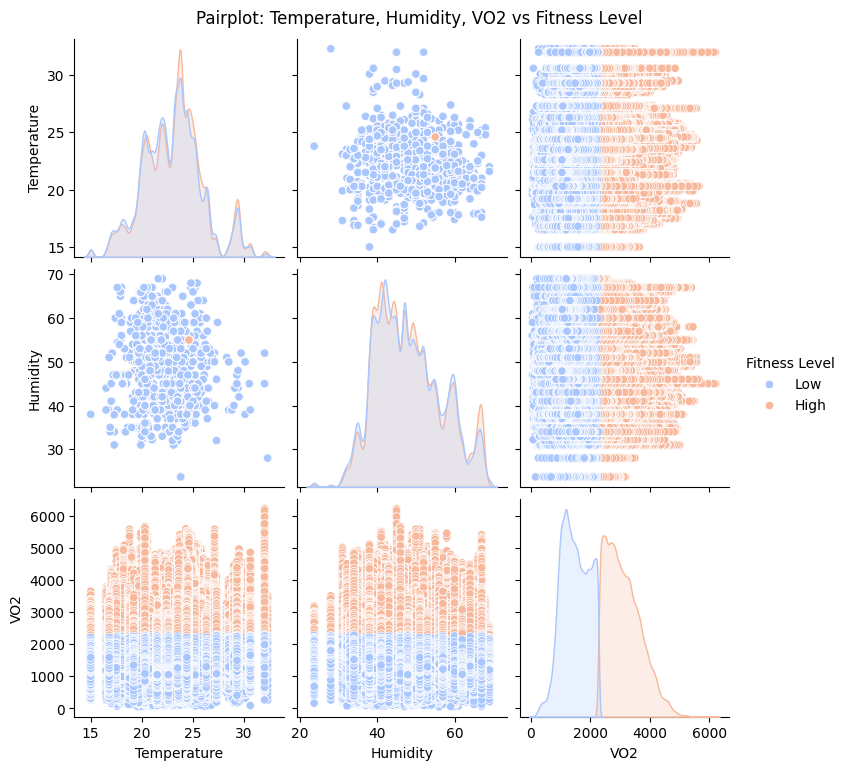

In [8]:
#48."Use a pairplot to analyze the relationship between temperature, humidity, and  VO2 max (ml/kg/min) across different fitness levels
#Hint :Classify ""Fitness Level"" as ""Low"" if VO2 max (ml/kg/min) is below the median, otherwise classify as ""High."

df_merge = pd.merge(df_test, df_subject, on='ID').dropna(subset=['Temperature', 'Humidity', 'VO2'])

#calculating median of VO2
median_vo2 = df_merge['VO2'].median()

#classifying fitness level
def fitness_level(vo2):
    if vo2 < median_vo2:
        return 'Low'
    else:
        return 'High'
    
#Applying the function to create a new column for Fitness Level   
df_merge['Fitness Level'] = df_merge['VO2'].apply(fitness_level)

#Plotting
sns.pairplot(df_merge, vars=['Temperature', 'Humidity', 'VO2'], hue='Fitness Level', palette='coolwarm')
plt.suptitle("Pairplot: Temperature, Humidity, VO2 vs Fitness Level",y=1.02)
plt.show()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn
import scipy.stats as stat
import altair as alt
import timeit

In [3]:
df_subject_info = pd.read_csv ('subject-info.csv') 
df_test_measure = pd.read_csv ('test_measure.csv')
#Merge the datasets on ID
merged_data = pd.merge (df_subject_info, df_test_measure, on='ID')

In [13]:
#49. Identify the test name that had the shortest time duration. 

#Group by ID_test and calculate the duration of each test
test_duration = df_test_measure.groupby ('ID_test')['time'].max().reset_index()
#Rename the columns
test_duration.columns = ['ID_test', 'duration']
#Find the test with the shortest duration
shortest_test = test_duration.loc [test_duration['duration'].idxmin()]
print ("The test name with the shortest duration is:", shortest_test['ID_test'])

The test name with the shortest duration is: 564_1


In [14]:
#50. What is the percentage difference in mean Carbon dioxide production between male and female athletes?

#Filter out the rows with missing VCO2 values
merged_data = merged_data.dropna (subset= ['VCO2'])
#Calculate mean VCO2 by sex
mean_male_vco2 = merged_data [merged_data ['Sex'] == 0] ['VCO2'].mean()
mean_female_vco2 = merged_data [merged_data ['Sex'] == 1] ['VCO2'].mean()
#Calculate percentage diff
percentage_diff = ((mean_male_vco2 - mean_female_vco2) / mean_female_vco2) * 100
print ("Percentage difference in mean Carbon dioxide production between male and female athletes:", percentage_diff)  

Percentage difference in mean Carbon dioxide production between male and female athletes: 41.430933327674005


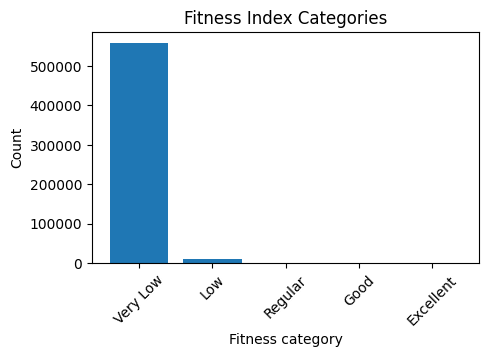

In [15]:
#51. Calculate the Fitness Index, generate a bar chart of Fitness Index categories, and export it as SVG file.

#Merge the datasets on ID_test
merged_data = pd.merge (df_subject_info, df_test_measure, on='ID_test')
#Calculate Fitness Index
merged_data['Fitness Index'] = (merged_data['Speed']*100) / (merged_data['Weight'] * (50/merged_data['Age']))
#Categorize Fitness Index
bins = [0,20,40,60,80,100]
labels = ['Very Low', 'Low', 'Regular', 'Good', 'Excellent']
merged_data['Fitness category'] = pd.cut (merged_data['Fitness Index'], bins= bins, labels= labels)
#Calculate count of each category 
category_counts = merged_data['Fitness category'].value_counts()
#Generate bar chart
plt.figure (figsize= (5,3))
plt.bar (category_counts.index, category_counts.values)
plt.xlabel ('Fitness category')
plt.ylabel ('Count')
plt.title ('Fitness Index Categories')
plt.xticks (rotation= 45)
#Export as SVG file
plt.savefig ('fitness_index_cateories', bbox_inches= 'tight')


In [16]:
#52. "arr=np.array([ [3, 5, 7, 9], [2, 0, 8, 10], [1, 4, 8, 12], [5, 9, 14, 15] ])
#Transpose this numpy matrix. and calculate sum of each row after transposing. Find the row with highest sum(after transposing)

arr = np.array([ [3, 5, 7, 9], [2, 0, 8, 10], [1, 4, 8, 12], [5, 9, 14, 15] ])
#Transpose the array
transposed_arr = arr.T
#Calculate the sum of each row after transposing
row_sums = np.sum (transposed_arr, axis=1)
#Find the row with highest sum
highest_sum_index = np.argmax (row_sums)
highest_sum_row = transposed_arr[highest_sum_index]
#Calculate maximum sum value
max_sum = np.max (row_sums)
print ("Original Array:\n", arr)
print ("\nTransposed Array:\n", transposed_arr)
print ("\nSum of each row after transposing:\n", row_sums)
print ("\nRow with highest sum:\n", highest_sum_row)
print ("\nmaximum sum value:", max_sum) 

Original Array:
 [[ 3  5  7  9]
 [ 2  0  8 10]
 [ 1  4  8 12]
 [ 5  9 14 15]]

Transposed Array:
 [[ 3  2  1  5]
 [ 5  0  4  9]
 [ 7  8  8 14]
 [ 9 10 12 15]]

Sum of each row after transposing:
 [11 18 37 46]

Row with highest sum:
 [ 9 10 12 15]

maximum sum value: 46


In [19]:
#53 Display participant details with highest average cardiorespiratory fitness in terms of VO2 max.

#Calculating VO2 max
merged_data['VO2_max'] =  merged_data['VO2'] / merged_data['Weight']
#Calculating average VO2 max for each participant
avg_VO2_max = merged_data.groupby('ID')['VO2_max'].mean().reset_index()
#Finding the participant with the highest average VO2 max
highest_avg_VO2_max_participant = avg_VO2_max.loc [avg_VO2_max['VO2_max'].idxmax()]
#Getting the participant's details
participant_details = df_subject_info.loc [df_subject_info['ID'] == highest_avg_VO2_max_participant['ID']]
print (participant_details)

      Age  Weight  Height  Humidity  Temperature  Sex   ID ID_test
350  23.6    86.0   190.0      45.0         32.0    0  409   409_1


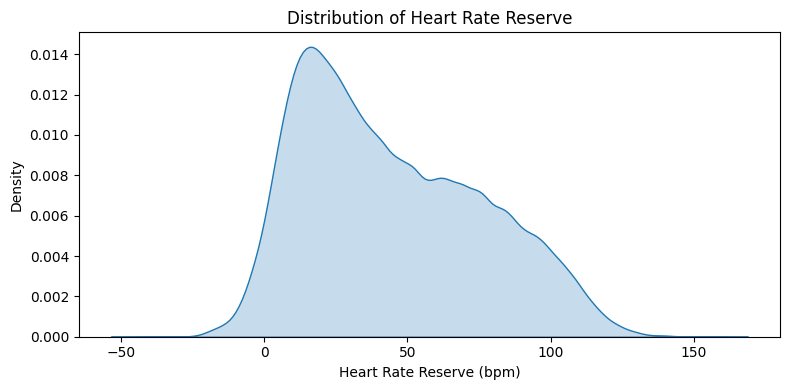

In [20]:
#54 calculate the heart rate reserve and show the distribution as density plot

#Calculate the maximum heart rate for each participant
merged_data['Max_HR'] = 220 - merged_data['Age']
#Calculate the heart rate reserve for each participant
merged_data['HRR'] = merged_data['Max_HR'] - merged_data['HR']
#Genarate the density plot
plt.figure (figsize= (8,4))
sbn.kdeplot (merged_data['HRR'], fill= True)
plt.title ('Distribution of Heart Rate Reserve')
plt.xlabel ('Heart Rate Reserve (bpm)')
plt.ylabel ('Density')
plt.tight_layout()
plt.show()

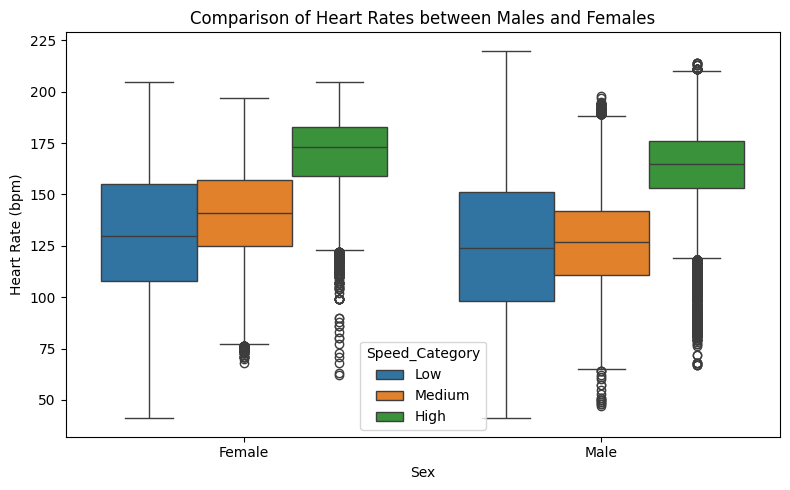

In [21]:
#55. Create a boxplot comparing heart rates between males and females, showing hue as speed category.

#Create a new column for speed category 
merged_data['Speed_Category'] = pd.cut (merged_data['Speed'], bins= [0,5,10,15], labels= ['Low', 'Medium', 'High'])
#Map sex values to male and female
merged_data['Sex'] = merged_data['Sex'].map({0: 'Male', 1: 'Female'})
#Create a boxplot
plt.figure (figsize= (8,5))
sbn.boxplot (data= merged_data, x= 'Sex', y= 'HR', hue= 'Speed_Category')
plt.title ('Comparison of Heart Rates between Males and Females')
plt.xlabel ('Sex')
plt.ylabel ('Heart Rate (bpm)')
plt.tight_layout()
plt.show()

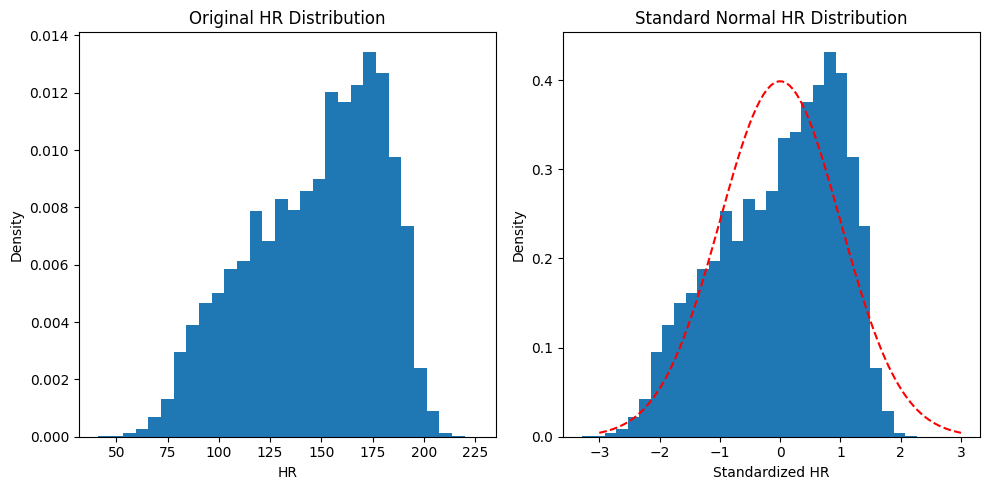

In [22]:
#56. Choose any feature that follows a Gaussian distribution, convert it into a standard normal distribution, and visualize the results?

#Select the HR feature
hr = df_test_measure['HR']
#Calculate the mean and standard deviation
mean = hr.mean()
std_dev = hr.std()
#Convert the HR feature into standard normal distribution 
std_normal_hr = (hr-mean)/std_dev
#Plot the original HR feature
plt.figure (figsize= (10,5))
plt.subplot (1,2,1)
plt.hist (hr, bins= 30, density= True)
plt.title ('Original HR Distribution')
plt.xlabel ('HR')
plt.ylabel ('Density')
#Plot the standard normal HR feature
plt.subplot (1,2,2)
plt.hist (std_normal_hr, bins= 30, density= True)
plt.title ('Standard Normal HR Distribution')
plt.xlabel ('Standardized HR')
plt.ylabel ('Density')
x = np.linspace (-3,3,100)
plt.plot (x, stat.norm.pdf(x,0,1), 'r--')
plt.tight_layout()
plt.show()

In [23]:
#57. Identify the participant who has taken maximum number of Graded Exercise test and justify.

#Count the number of test per participant
GET_Count = df_subject_info['ID'].value_counts()
#Identify the participant with the maximum number of tests
max_GET_participant = GET_Count.idxmax()
max_GET_count = GET_Count.max()
print (f"Participant {max_GET_participant} has taken the maximum number of tests: {max_GET_count}")

#Justification:
#The participant with the maximum number of tests can be identified by counting the number of roes in the subject-info.csv file for each unique ID.
#The value_counts() method in pandas provide a convenient method to perform this count. The participant with the highest count is the one who has taken
#the maximum number of GETS

Participant 506 has taken the maximum number of tests: 5


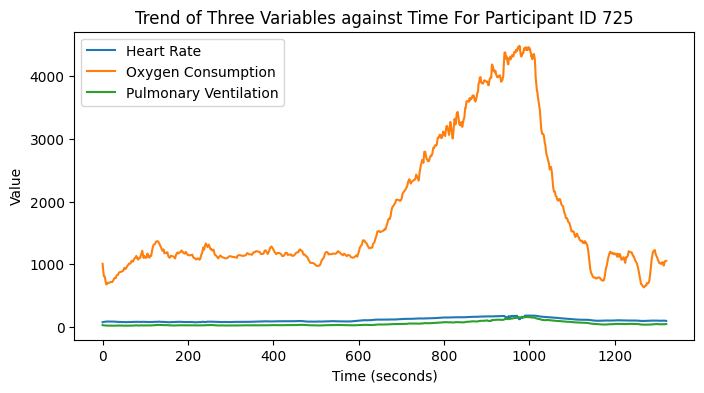

In [24]:
#58. For participant ID 725 show trend of  any three variables against time in a single canva ?

#Filter the data for participant ID 725
participant_data = df_test_measure [df_test_measure ['ID'] == 725]
#Plot the trend of three variables against time
plt.figure (figsize= (8,4))
plt.plot (participant_data['time'], participant_data['HR'], label= 'Heart Rate')
plt.plot (participant_data['time'], participant_data['VO2'], label= 'Oxygen Consumption')
plt.plot (participant_data['time'], participant_data['VE'], label= 'Pulmonary Ventilation')
plt.xlabel ('Time (seconds)')
plt.ylabel ('Value')
plt.title ('Trend of Three Variables against Time For Participant ID 725')
plt.legend()
plt.show()

In [25]:
#59. Create a scatter plot with a regression line using Altair, take a random sample data with features 'x' and 'y'.

#Take a random sample of 1000 rows
sample_data = df_test_measure [['HR', 'VO2']].sample (n=1000).rename (columns={'HR': 'x', 'VO2':'y'})
#Create scatter plot
chart = alt.Chart(sample_data).mark_point().encode(
    x=alt.X('x:Q', title= 'Heart Rate (beats/min)'),
    y=alt.Y('y:Q', title= 'Oxygen Consumption (ml/min)')
)
#Add regression line to the scatter plot
regression_line = chart.transform_regression ('x', 'y').mark_line (color= 'red')
#Combine the scatter plot and regression line into a single chart
final_chart = (chart + regression_line).properties (title= 'Relationship between Heart Rate and Oxygen Consumption')
final_chart

alt.LayerChart(...)

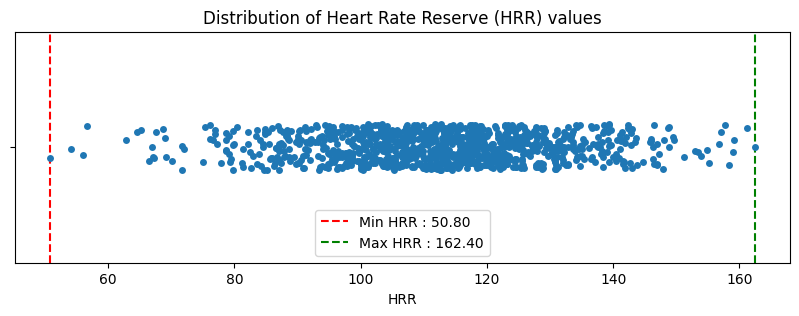

In [26]:
#60 Use a strip plot to illustrate the distribution of Heart Rate Reserve (HRR) values, highlighting the lowest and highest values to showcase the range of HRR.

merged_data = pd.merge (df_subject_info, df_test_measure, on='ID_test')
#Calculate maximum Heart Rate
merged_data['HRmax'] = 220 - merged_data['Age']
#Calculate resting Heart Rate
HR_rest = merged_data.groupby('ID_test')['HR'].min().reset_index()
HR_rest = HR_rest.rename (columns= {'HR' : 'HRrest'})
#Merging HR_rest with merged_data
merged_data = pd.merge (merged_data, HR_rest, on= 'ID_test')
#Calculate Heart Rate Reserve (HRR)
merged_data['HRR'] = merged_data['HRmax'] - merged_data['HRrest']
#Create strip plot of HRR values and drop_duplicates('ID_test') ensures that each participant is only represented once in the plot
plt.figure (figsize= (10,3))
sbn.stripplot (data= merged_data.drop_duplicates('ID_test'), x= 'HRR')
plt.title ('Distribution of Heart Rate Reserve (HRR) values')
#Highlight lowest and highest HRR values
min_HRR = merged_data['HRR'].min()
max_HRR = merged_data['HRR'].max()
plt.axvline (x= min_HRR, color= 'red', linestyle= '--', label= f'Min HRR : {min_HRR:.2f}')
plt.axvline (x= max_HRR, color= 'green', linestyle= '--', label= f'Max HRR : {max_HRR:.2f}')
#Display the labels for the minimum and maximum HRR lines
plt.legend()
plt.show()
#Calculate the minimum heart rate as HR_rest for each participant by grouping the data by ID_test and taking the minimum value of HR

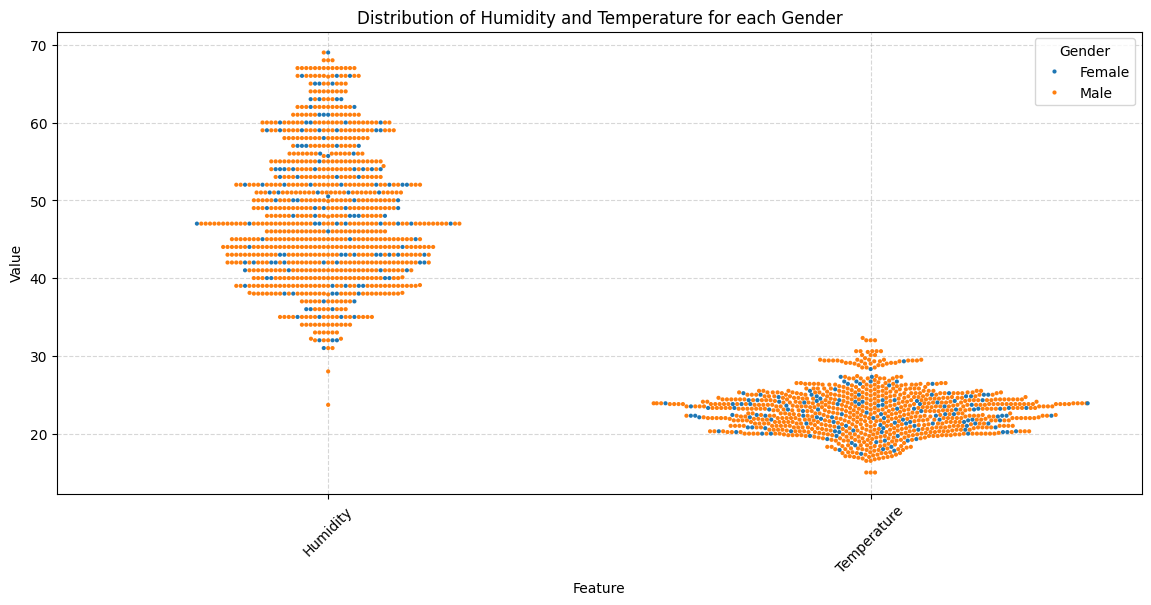

In [4]:
#61. Create a swarm plot to visualize the relationship between humidity and temperature for each gender.

#Map sex values to male and female
df_subject_info['Sex'] = df_subject_info['Sex'].map ({0:'Male', 1:'Female'})
#Drop rows with missing humidity or temperature values
df_subject_info = df_subject_info.dropna (subset= ['Humidity', 'Temperature'])
#Melt the data frame
melted_df = df_subject_info.melt (id_vars= ['Sex'], value_vars= ['Humidity', 'Temperature'], var_name= 'Feature', value_name= 'Value')
#Create swarm plot
plt.figure (figsize= (14,6))
sbn.swarmplot (data= melted_df, x= 'Feature', y= 'Value', hue= 'Sex', size= 3)
plt.title ('Distribution of Humidity and Temperature for each Gender')
plt.xlabel ('Feature')
plt.ylabel('Value')
plt.legend (title= 'Gender')
plt.xticks (rotation= 45)
plt.grid (True, linestyle= '--', alpha= 0.5)
plt.show()

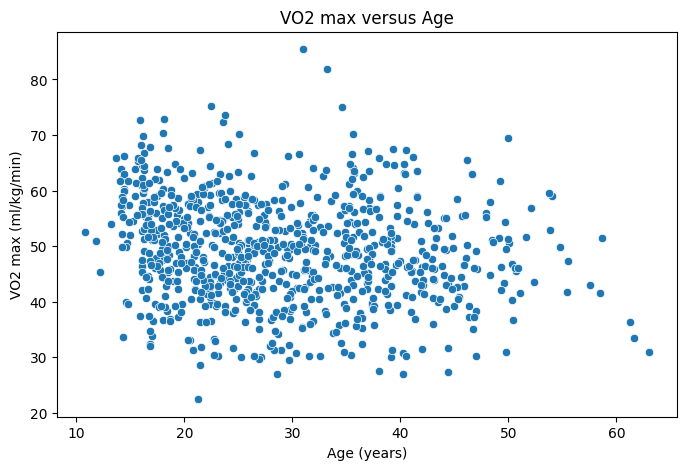

In [5]:
#62. Analyze the relationship between fitness levels and physiological attributes and identify trends in the scatter plot of VO2 max (ml/kg/min) versus age

merged_data = pd.merge (df_subject_info, df_test_measure, on= 'ID')
#Drop rows with missing values in the VO2 column
merged_data = merged_data.dropna (subset= ['VO2'])
#Calculate the index of the maximum VO2 value for each participant. Select the rows from the merged dataframe where the index matches the index of the max VO2 value
df_VO2_max = merged_data.loc [merged_data.groupby ('ID')['VO2'].idxmax()]
#Calculate the VO2 max
df_VO2_max['VO2max'] = df_VO2_max['VO2'] / df_VO2_max['Weight']
#Creates a scatter plot
plt.figure (figsize= (8,5))
sbn.scatterplot (data= df_VO2_max, x= 'Age', y= 'VO2max')
plt.title ('VO2 max versus Age')
plt.xlabel('Age (years)')
plt.ylabel ('VO2 max (ml/kg/min)')
plt.show()
#Calculating VO@max for each participant and then plotting it against their age

In [6]:
#63 Calculate the warm-up time, GET time, cool-down time, for each athlete test and find athlete who has maximum GET time ?

#Calculate 60% of maximum heart rate to determine the warm-up threshold. Calculate 80% of maximum heart rate to determine the GET threshold.
#Calculate the cool-down time by subtracting the GET time from the maximum time.
#Calculate Maximum heart rate
df_subject_info['Max_HR'] = 220 - df_subject_info['Age']
#Merge data frames
merged_data = pd.merge(df_test_measure, df_subject_info, on='ID_test')
#Initialize lists
id_tests = []
warm_up_times = []
cool_down_times = []
get_times = []
#Loop through unique test IDs and filter data for current test ID
for test_ID in merged_data['ID_test'].unique():
    test_data = merged_data[merged_data['ID_test'] == test_ID]
    #Check if data is empty
    if test_data.empty:
        continue
    #Calculate warm-up heart rate    
    warm_up_hr = test_data['Max_HR'].iloc[0] * 0.6
    #Filter data for warm-up
    warm_up_data = test_data[test_data['HR'] >= warm_up_hr]
    #Handle missing warm-up time
    if not warm_up_data.empty:
        warm_up_time = warm_up_data['time'].min()
    else:
        warm_up_time = None
    #Calculate get heart rate    
    get_hr = test_data['Max_HR'].iloc[0] * 0.8
    get_data = test_data[test_data['HR'] >= get_hr]
    #Calculate get time
    if not get_data.empty:
        get_time = get_data['time'].min()
    else:
        get_time = None
    #Calculate cool-down time
    if get_time is not None:
        cool_down_time = test_data['time'].max() - get_time
    else:
        cool_down_time = None
    #Append values to lists
    id_tests.append (test_ID)
    warm_up_times.append (warm_up_time)
    get_times.append (get_time)
    cool_down_times.append (cool_down_time)
#Create Dataframe
times_df = pd.DataFrame ({'ID_test': id_tests, 'Warm_up_time': warm_up_times, 'Get_time': get_times, 'Cool_down_time': cool_down_times})
print ("Warm-up time, GET time, Cool-down time for each athlete test:")
print (times_df)
#Drop rows with missing get time
times_df = times_df.dropna (subset= ['Get_time'])
if not times_df.empty:
    max_get_time = times_df.loc[times_df['Get_time'].idxmax()]
    max_get_time_athlete_id = df_subject_info.loc[df_subject_info['ID_test'] == max_get_time['ID_test'], 'ID'].iloc[0]
    print (f"Athlete with maximum GET time: {max_get_time_athlete_id}")
    print (f"Maximum GET time: {max_get_time['Get_time']}")
else:
    print("No GET time data available")

Warm-up time, GET time, Cool-down time for each athlete test:
    ID_test  Warm_up_time  Get_time  Cool_down_time
0       3_1           119     366.0           607.0
1       9_1             4     338.0           557.0
2      10_1            28     408.0           678.0
3      11_1           235     433.0           411.0
4      12_1             4     238.0           481.0
..      ...           ...       ...             ...
957   855_1           404     670.0           557.0
958   856_3           335     614.0           739.0
959   856_2           342     603.0           656.0
960   856_1           328     571.0           519.0
961   857_1            19     397.0           536.0

[962 rows x 4 columns]
Athlete with maximum GET time: 351
Maximum GET time: 1156.0


In [7]:
#64 Compare the time it takes to multiply each element in a large array by 2 using an explicit loop and a vectorized operation with NumPy 

#Create a large Numpy array
arr = np.arange (1000000)
#Measure the time taken for the explicit loop approach
exp_loop_time = timeit.timeit (lambda: np.array ([x*2 for x in arr]) , number = 1)
print (f"Explicit loop time : {exp_loop_time : .4f} seconds")
#Measure the time taken for the vectorized operation approach
vectorized_time = timeit.timeit (lambda: arr * 2 , number = 1)
print (f"Vectorized Operation time : {vectorized_time : .4f} seconds")
#Compare the explicit loop time and vectorized time
print (f"Vectorized Operation is {exp_loop_time / vectorized_time:.2f}x times faster") 
#number=10 means that the code snippet should be executed 1 time
#Vectorized operations are much faster than loops

Explicit loop time :  0.7685 seconds
Vectorized Operation time :  0.0092 seconds
Vectorized Operation is 83.15x times faster


In [9]:
subject_data= pd.read_csv('subject-info.csv')
test_data = pd.read_csv('test_measure.csv')
merged_data = pd.merge(subject_data,test_data, on='ID')


In [10]:
# 65. Calculate the percentage of male athletes who exceeded, the maximum treadmill speed of female athletes.

#step1: find max speed of female
female_merged_data= merged_data[merged_data['Sex'] == 1]
max_female_speed = female_merged_data['Speed'].max()

#step2: find max speed of male
Male_merged_data= merged_data[merged_data['Sex'] == 0]
max_Male_speed = Male_merged_data['Speed'].max()

#step3: find no of male athletes who exceeded maximum female speed.
Male_exceeding =Male_merged_data[Male_merged_data['Speed']>max_female_speed]

#step4: to remove duplicate ID
Male_exceeding_count = Male_exceeding['ID'].nunique()
Male_merged_data_count = Male_merged_data['ID'].nunique()
Percentage = Male_exceeding_count/Male_merged_data_count*100

print(Percentage)

9.641873278236915


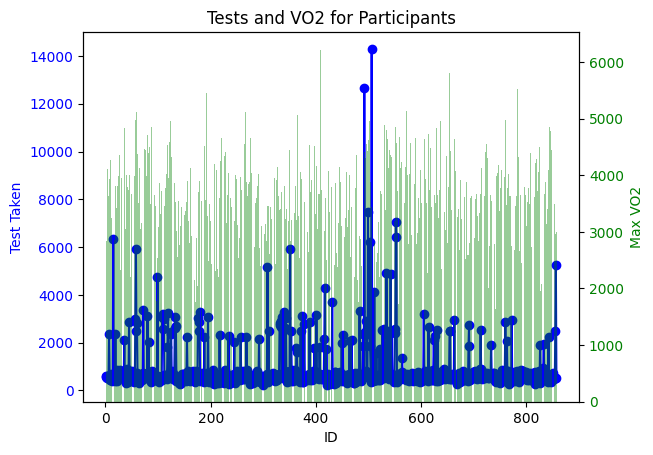

In [11]:
# 66. Visualize the number of test taken by participants and their trend of maximum Vo2 level as dual chart ?
import matplotlib.pyplot as plt

tests_taken = merged_data.groupby('ID')['ID_test_x'].count().reset_index()
max_vo2 = merged_data.groupby('ID')['VO2'].max().reset_index()

# Create figure and first axis
fig, ax1 = plt.subplots()

# Plot on first y-axis
ax1.set_xlabel('ID')
ax1.set_ylabel('Test Taken', color='blue')
ax1.plot(tests_taken["ID"], tests_taken["ID_test_x"], color='blue', marker='o')
ax1.tick_params(axis='y', labelcolor='blue')

# Create second y-axis sharing the same x-axis
ax2 = ax1.twinx()
ax2.set_ylabel('Max VO2', color='green')
ax2.bar(max_vo2["ID"], max_vo2["VO2"], color='green', alpha=0.4)
ax2.tick_params(axis='y', labelcolor='green')

# Title and show
plt.title('Tests and VO2 for Participants')
plt.show()

Text(0, 0.5, 'Speed')

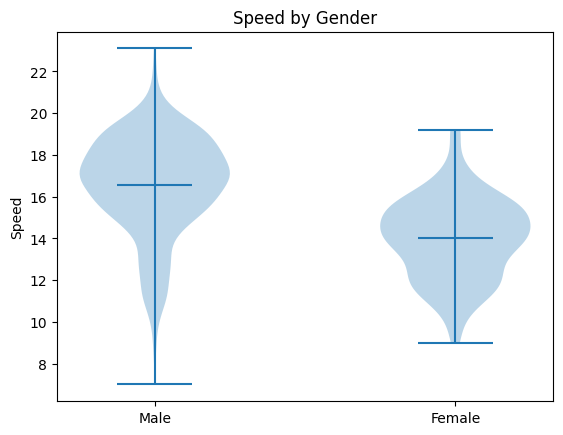

In [12]:
# 67. Create violin chart for any two column from the dataset ?



max_male_speeds = Male_merged_data.groupby('ID')['Speed'].max().reset_index()
max_female_speeds = female_merged_data.groupby('ID')['Speed'].max().reset_index()

plt.violinplot([max_male_speeds["Speed"], max_female_speeds["Speed"]], showmeans=True)
plt.xticks([1, 2], ['Male', 'Female'])
plt.title('Speed by Gender')
plt.ylabel('Speed')

In [13]:
# 68. calculate BSA (Body surface area) without using function and store as column in dataframe and categorize . 
merged_data['BSA'] = np.sqrt(merged_data['Height']*merged_data['Weight']/3600)

def categorize_bsa(value):
    if value < 1.5:
        return 'Low'
    elif 1.5 <= value <= 2.0:
        return 'Normal'
    else:
        return 'High'

merged_data['BSA_Category'] = merged_data['BSA'].apply(categorize_bsa)

# merged_data['BSA_Category_2'] = merged_data['BSA'].apply(
#     lambda x: 'Low' if x < 1.5 else ('Normal' if x <= 2.0 else 'High')
# )

print(merged_data)

         Age  Weight  Height  Humidity  Temperature  Sex   ID ID_test_x  time  \
0       10.8    48.8   163.0      39.0         20.7    1  543     543_1     0   
1       10.8    48.8   163.0      39.0         20.7    1  543     543_1     3   
2       10.8    48.8   163.0      39.0         20.7    1  543     543_1    10   
3       10.8    48.8   163.0      39.0         20.7    1  543     543_1    13   
4       10.8    48.8   163.0      39.0         20.7    1  543     543_1    17   
...      ...     ...     ...       ...          ...  ...  ...       ...   ...   
773613  63.0    83.5   171.5      48.0         22.2    0  296     296_1   747   
773614  63.0    83.5   171.5      48.0         22.2    0  296     296_1   749   
773615  63.0    83.5   171.5      48.0         22.2    0  296     296_1   752   
773616  63.0    83.5   171.5      48.0         22.2    0  296     296_1   754   
773617  63.0    83.5   171.5      48.0         22.2    0  296     296_1   757   

        Speed     HR     VO

In [14]:
# 69. Write a python function that efficiently processes large data into chunks to analyze average heart rate and maximum oxygen consumption 
# for each test. Print the chunks during processing.

subject_data= pd.read_csv('subject-info.csv')

test_chunksize = 10000
hr = {}
o2 = {}

for chunk in pd.read_csv('test_measure.csv', chunksize=test_chunksize):

    print(f'Processing {chunk.shape[0]} rows')
    
    merged_chunk = pd.merge(subject_data,chunk, on='ID')
    # Splt ID_test
    # merged_chunk[['ID2', 'Test']] = merged_chunk['ID_test'].str.split('_', expand=True)

    # Calculate max of HR and max O2
    merged_chunk['Max VO2'] = merged_chunk['VO2']/merged_chunk['Weight']
    merged_chunk['Max HR'] = 220 - merged_chunk['Age']


Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing 10000 rows
Processing

C:\Users\chait\AppData\Local\Temp\ipykernel_9780\1412859786.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vco2 = merged_data.groupby('VE_bin')['VCO2'].mean().reset_index()
C:\Users\chait\AppData\Local\Temp\ipykernel_9780\1412859786.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  o2 = merged_data.groupby('VE_bin')['VO2'].mean().reset_index()


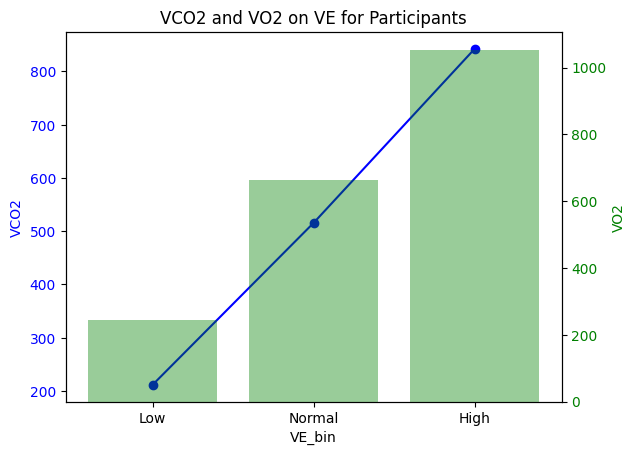

In [15]:
# 70. "How does the body's production of carbon dioxide related to the consumption of oxygen with increasing levels of pulmonary ventilation during GET? 
# Use low, medium, and high bins values for VE to find your observations."

merged_data['VE_bin'] = pd.cut(merged_data['VE'], bins=[0,10,20,30], labels=['Low', 'Normal', 'High'], right=False)

vco2 = merged_data.groupby('VE_bin')['VCO2'].mean().reset_index()
o2 = merged_data.groupby('VE_bin')['VO2'].mean().reset_index()

# Create figure and first axis
fig, ax1 = plt.subplots()

# Plot on first y-axis
ax1.set_xlabel('VE_bin')
ax1.set_ylabel('VCO2', color='blue')
ax1.plot(vco2["VE_bin"], vco2["VCO2"], color='blue', marker='o')
ax1.tick_params(axis='y', labelcolor='blue')

# Create second y-axis sharing the same x-axis
ax2 = ax1.twinx()
ax2.set_ylabel('VO2', color='green')
ax2.bar(o2["VE_bin"], o2["VO2"], color='green', alpha=0.4)
ax2.tick_params(axis='y', labelcolor='green')

# Title and show
plt.title('VCO2 and VO2 on VE for Participants')
plt.show()

C:\Users\chait\AppData\Local\Temp\ipykernel_9780\4128758578.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_grouped_data = merged_data.groupby('Age_Category')['ID'].nunique().reset_index()


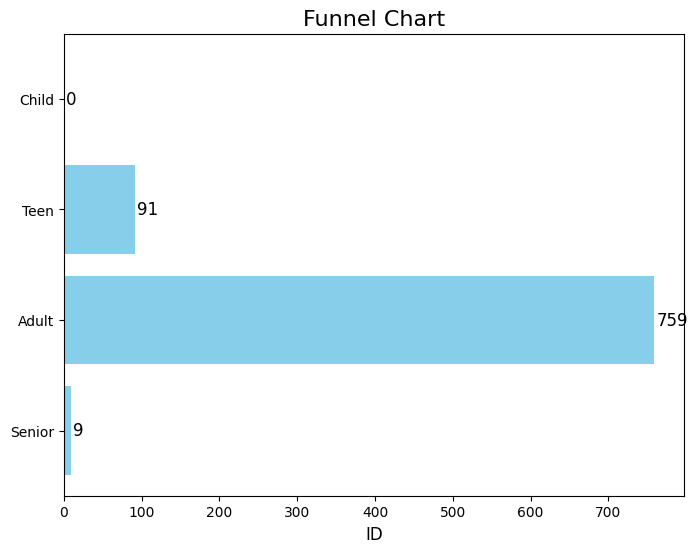

In [16]:
# 71. Create a Funnel chart of Age Category (Child, Teen, Adult and Senior) ?

merged_data['Age_Category'] = pd.cut(merged_data['Age'], bins=[0,9,17,55,100], labels=['Child', 'Teen', 'Adult', 'Senior'], right=False)
age_grouped_data = merged_data.groupby('Age_Category')['ID'].nunique().reset_index()

# Create figure and axes
fig, ax = plt.subplots(figsize=(8, 6))

# Create horizontal bars, but the widths will decrease
ax.barh(age_grouped_data['Age_Category'], age_grouped_data['ID'], color='skyblue')

# Add labels
for i, value in enumerate(age_grouped_data['ID']):
    ax.text(value + 3, i, f'{value}', va='center', ha='left', fontsize=12)

# Invert the y-axis to make it top-down
ax.invert_yaxis()

# Title and labels
ax.set_title('Funnel Chart', fontsize=16)
ax.set_xlabel('ID', fontsize=12)

# Show the chart
plt.show()

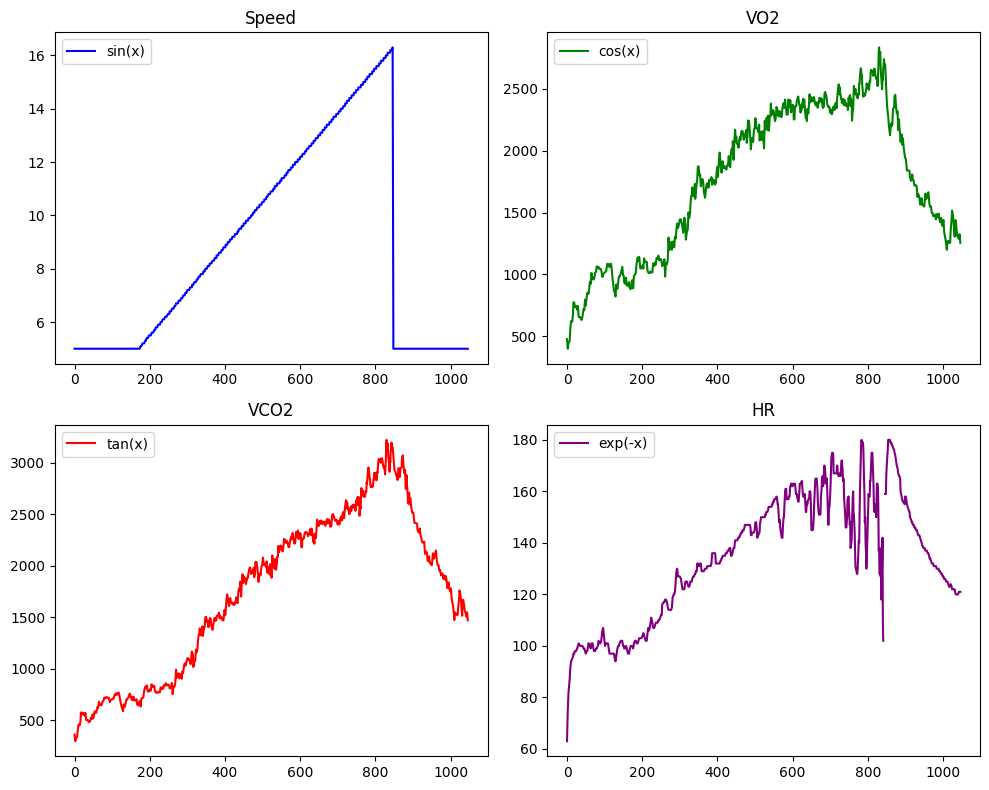

In [17]:
# 72. visualize different physiological parameters over time for a specific test of an athlete 
# using multiple panels?
filtered_data = merged_data[merged_data['ID_test_x']=='2_1']

x = filtered_data['time']
y1 = filtered_data['Speed']
y2 = filtered_data['VO2']
y3 = filtered_data['VCO2']
y4 = filtered_data['HR']

# Create a figure with 2 rows and 2 columns of subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 8))  # (rows, columns)

# Plot data on each subplot
axs[0, 0].plot(x, y1, label='sin(x)', color='blue')
axs[0, 0].set_title('Speed')
axs[0, 0].legend()

axs[0, 1].plot(x, y2, label='cos(x)', color='green')
axs[0, 1].set_title('VO2')
axs[0, 1].legend()

axs[1, 0].plot(x, y3, label='tan(x)', color='red')
axs[1, 0].set_title('VCO2')
axs[1, 0].legend()

axs[1, 1].plot(x, y4, label='exp(-x)', color='purple')
axs[1, 1].set_title('HR')
axs[1, 1].legend()

# Adjust layout to avoid overlapping titles/labels
plt.tight_layout()

# Display the figure with all subplots
plt.show()

In [18]:
# 73. Print first 10 records of the subject_info based on ID, without using head() method.
# Select the first 10 records using slicing
first_10_records = subject_data[:10]

# Print the result
print(first_10_records)

    Age  Weight  Height  Humidity  Temperature  Sex   ID ID_test
0  10.8    48.8   163.0      39.0         20.7    1  543   543_1
1  11.8    41.0   150.0      41.0         22.3    1   11    11_1
2  12.2    46.0   160.0      37.0         21.5    0  829   829_1
3  13.2    71.0   190.0      49.0         23.8    1  284   284_1
4  13.7    53.8   169.7      40.0         25.3    0  341   341_1
5  13.8    53.4   171.0      42.0         24.4    0  341   341_2
6  14.0    46.0   160.0      40.0         25.3    0  343   343_1
7  14.1    50.0   168.9      42.0         24.2    0  330   330_1
8  14.1    47.2   160.2      40.0         25.2    0  338   338_1
9  14.1    49.7   160.1      40.0         25.8    0  339   339_1


In [19]:
# 74. Determine the treadmill speed range and age range in which you observe the highest 
# average heart rate.

merged_data['Speed_Category'] = pd.cut(merged_data['Speed'], bins=[0,10,20,30], labels=['Slow', 'Average', 'Fast'], right=False)

age_grouped_data_hr = merged_data.groupby('Age_Category')['HR'].max().reset_index()
speed_grouped_data_hr = merged_data.groupby('Speed_Category')['HR'].max().reset_index()

print(age_grouped_data_hr)
print(speed_grouped_data_hr)


  Age_Category     HR
0        Child    NaN
1         Teen  220.0
2        Adult  226.0
3       Senior  197.0
  Speed_Category     HR
0           Slow  220.0
1        Average  226.0
2           Fast  202.0


C:\Users\chait\AppData\Local\Temp\ipykernel_9780\3011491736.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_grouped_data_hr = merged_data.groupby('Age_Category')['HR'].max().reset_index()
C:\Users\chait\AppData\Local\Temp\ipykernel_9780\3011491736.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  speed_grouped_data_hr = merged_data.groupby('Speed_Category')['HR'].max().reset_index()


In [20]:
# 75. Identify subjects whose heart rate (HR) is consistently above their age group’s 75th percentile.
age_grouped_data_hr_75_percentil = merged_data.groupby('Age_Category')['HR'].quantile(0.75).reset_index()

def check_if_hr_above_75(x_value):
    matched_age = age_grouped_data_hr_75_percentil[age_grouped_data_hr_75_percentil['Age_Category'].apply(lambda x:x == x_value['Age_Category'])]
    return matched_age['HR'] > x_value['HR']
merged_data['75th_HR_Quartile'] = merged_data[:10000].apply(check_if_hr_above_75, axis=1)
merged_data[merged_data['75th_HR_Quartile'].fillna(False)]['ID'].unique()


C:\Users\chait\AppData\Local\Temp\ipykernel_9780\1852152781.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_grouped_data_hr_75_percentil = merged_data.groupby('Age_Category')['HR'].quantile(0.75).reset_index()
C:\Users\chait\AppData\Local\Temp\ipykernel_9780\1852152781.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged_data[merged_data['75th_HR_Quartile'].fillna(False)]['ID'].unique()


array([543,  11, 829, 284, 341, 343, 330, 338, 339])

In [21]:
# 76. list the participants ID and test _ID who started their warm up with speed less than 5km/h ?
merged_data[merged_data['time'] == 0][merged_data['Speed']<5]['ID']

C:\Users\chait\AppData\Local\Temp\ipykernel_9780\1920628034.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  merged_data[merged_data['time'] == 0][merged_data['Speed']<5]['ID']


0         543
1347      829
14467     607
23347     332
26281     336
         ... 
770059    856
770576    856
771195    856
771815    856
772847    596
Name: ID, Length: 379, dtype: int64

In [35]:
# 77. Calculate the mean VO2 max for male and female athletes in the Get Phase.
female_merged_data.loc[:, 'VO2_max'] = female_merged_data.apply(lambda x: x['VO2']/x['Weight'], axis=1)
Male_merged_data.loc[:, 'VO2_max'] = Male_merged_data.apply(lambda x: x['VO2']/x['Weight'], axis=1)


print(f"VO2 max for male athletes: {round(float(Male_merged_data['VO2_max'].mean()), 2)}")
print(f"VO2 max for female athletes: {round(float(female_merged_data['VO2_max'].mean()), 2)}")

VO2 max for male athletes: 32.93
VO2 max for female athletes: 27.61


In [26]:
# 78. If you consider cool down time as the recovery period after reaching peak speed, 
# display the participant details who has taken the longest Cool Down time.
max_speeds_by_id = merged_data.groupby('ID')['Speed'].max().reset_index()
max_speeds_data = merged_data.merge(max_speeds_by_id, on=['ID', 'Speed'], how='inner')

max_times_by_id = merged_data.groupby('ID')['time'].max().reset_index()
max_times_data = merged_data.merge(max_times_by_id, on=['ID', 'time'], how='inner')

# print(max_times_data.shape[0])

max_times_data_renamed = max_times_data[['ID','time','Speed']].rename(columns={'Speed':'Speed_2','time':'time_2'})
merged_result = max_speeds_data.merge(max_times_data_renamed, on=['ID'], how='inner')
# print(merged_result)
merged_result['time_diff'] = merged_result.apply(lambda x : x['time_2'] - x['time'], axis=1)
max_id = merged_result.loc[merged_result['time_diff'].idxmax(), 'ID']
print(subject_data[subject_data['ID']==max_id][0:1])

      Age  Weight  Height  Humidity  Temperature  Sex   ID ID_test
277  21.7    66.0   168.0      42.0         23.5    1  826   826_1


In [30]:
# 79. Identify the athlete who recorded the highest treadmill speed during the tests.
athlete_high_speed = merged_data.loc[merged_data['Speed'].idxmax(), 'ID']
print(f"Athlete ID who recorded the highest treadmill speed during the tests:{athlete_high_speed} ")

Athlete ID who recorded the highest treadmill speed during the tests:431 


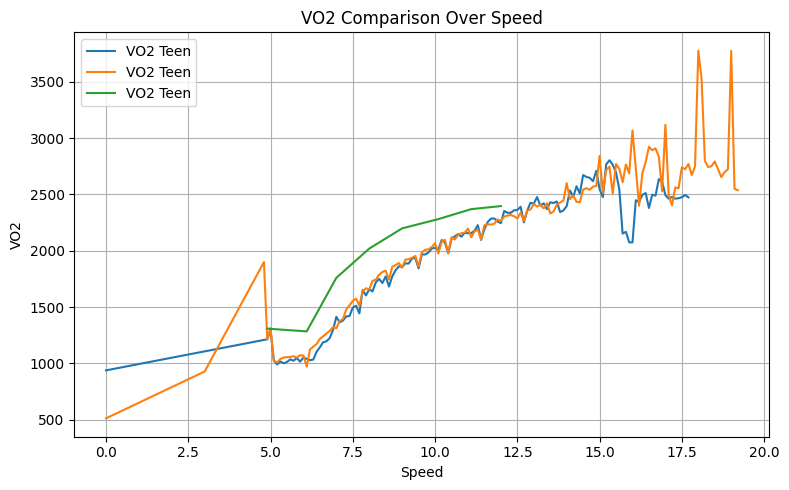

In [28]:
# 80. Show the oxygen consumption trend analysis among women athletes across different age groups 
teen_data = merged_data[(merged_data['Age_Category']=='Teen') & (merged_data['Sex']==1)]
teen_data_grouped = teen_data.groupby('Speed')['VO2'].mean().reset_index()
adult_data = merged_data[(merged_data['Age_Category']=='Adult') & (merged_data['Sex']==1)]
adult_data_grouped = adult_data.groupby('Speed')['VO2'].mean().reset_index()
senior_data = merged_data[(merged_data['Age_Category']=='Senior') & (merged_data['Sex']==1)]
senior_data_grouped = senior_data.groupby('Speed')['VO2'].mean().reset_index()

plt.figure(figsize=(8, 5))
plt.plot(teen_data_grouped['Speed'], teen_data_grouped['VO2'], label='VO2 Teen')
plt.plot(adult_data_grouped['Speed'], adult_data_grouped['VO2'], label='VO2 Teen')
plt.plot(senior_data_grouped['Speed'], senior_data_grouped['VO2'], label='VO2 Teen')

# Labels and title
plt.xlabel('Speed')
plt.ylabel('VO2')
plt.title('VO2 Comparison Over Speed')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
